## 1: Data Loading & Temporal Splitting

In recommender system experiments, it is crucial to **split data by time** rather than randomly. Temporal splitting ensures that all interactions in the training set strictly precede those in validation and test sets, mirroring a real-world scenario where we train on past user behavior to predict the future. This approach:

* Prevents information leakage (where future data could accidentally inform past predictions),
* Produces more realistic evaluation metrics, and
* Ensures fair comparison with other models.

In our workflow, after loading all user session logs, we sort them by timestamp and split them into training (first 80%), validation (next 10%), and test (final 10%) sets. This way, the model will only be trained on user behaviors that occurred before the validation and test sessions, preserving temporal integrity.
Later, when building graphs or extracting features, each split will be used independently, and only the appropriate data subset (train/val/test) will be available to the corresponding model phase.

In [1]:
# import libraries for data loading and splitting
import pandas as pd
import numpy as np
import json
from datetime import datetime
from pathlib import Path
from collections import defaultdict
import logging
import psutil
import gc
from functools import wraps
import torch
import matplotlib.pyplot as plt
import networkx as nx

# Optional: Pretty display for logs
logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

#### Define File Paths

In [2]:
# Add file path definitions (adjust to your actual paths)
TRAIN_BEHAVIOR_PATH = Path('data/mind/small/train/behaviors.tsv')
DEV_BEHAVIOR_PATH   = Path('data/mind/small/dev/behaviors.tsv')
TRAIN_NEWS_PATH     = Path('data/mind/small/train/news_actant.jsonl')
DEV_NEWS_PATH       = Path('data/mind/small/dev/news_actant.jsonl')

## 1.1: Session Logs 

### 1.1.1: Load, Parse, Validate Session Logs

In [3]:
def parse_impressions(imp_string):
    """
    Parse the 'impressions' field from a MIND behavior log entry.
    
    Args:
        imp_string (str): Space-separated string like "N1-1 N2-0 N3-0"
                         where each item is "news_id-label" (1=clicked, 0=not clicked)
    
    Returns:
        list of tuple: [(news_id, label), ...] where label is 1 or 0
        
    Example:
        >>> parse_impressions("N1-1 N2-0")
        [('N1', 1), ('N2', 0)]
    """
    if pd.isna(imp_string):
        return []
    return [(x.split('-')[0], int(x.split('-')[1])) for x in imp_string.strip().split()]

def parse_history(history_string):
    """
    Parse the 'history' field from a MIND behavior log entry.
    
    Args:
        history_string (str): Space-separated string of previously clicked news IDs
                             Example: "N101 N205 N350"
    
    Returns:
        list of str: List of news_id strings
        
    Example:
        >>> parse_history("N101 N205 N350")
        ['N101', 'N205', 'N350']
    """
    if pd.isna(history_string) or history_string.strip() == "":
        return []
    return history_string.strip().split()

In [4]:
# Define column names as per MIND format
columns = ['impression_id', 'user_id', 'timestamp', 'history', 'impressions']

def load_behaviors(path):
    """Load and parse behavior data with memory optimization."""
    # Use category dtype for memory efficiency with repeated strings
    df = pd.read_csv(
        path, 
        sep='\t', 
        header=None, 
        names=columns, 
        quoting=3,
        dtype={'user_id': 'category'}  # Memory optimization for repeated user IDs
    )
    
    # Convert timestamp efficiently
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    
    # Parse structured fields
    df['history'] = df['history'].apply(parse_history)
    df['impressions'] = df['impressions'].apply(parse_impressions)
    
    logging.info(f"Loaded {len(df)} behavior records from {path}")
    return df

logging.info("=== STARTING DATA LOADING ===")
train_behaviors = load_behaviors(TRAIN_BEHAVIOR_PATH)
dev_behaviors = load_behaviors(DEV_BEHAVIOR_PATH)

INFO: === STARTING DATA LOADING ===
INFO: Loaded 156965 behavior records from data/mind/small/train/behaviors.tsv
INFO: Loaded 73152 behavior records from data/mind/small/dev/behaviors.tsv


In [5]:
def validate_behaviors_data(df, name="behaviors"):
    """
    Validate loaded behavior data and log statistics for explainability.
    
    Args:
        df: Loaded behaviors DataFrame
        name: Dataset name for logging
    """
    logging.info(f"\n=== {name.upper()} DATA VALIDATION ===")
    
    # Basic statistics
    logging.info(f"Total records: {len(df):,}")
    logging.info(f"Unique users: {df['user_id'].nunique():,}")
    logging.info(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")
    
    # History statistics
    history_lengths = df['history'].apply(len)
    logging.info(f"History length - Mean: {history_lengths.mean():.1f}, "
                f"Median: {history_lengths.median():.1f}, "
                f"Max: {history_lengths.max()}")
    
    # Impression statistics  
    impression_lengths = df['impressions'].apply(len)
    click_rates = df['impressions'].apply(lambda x: sum(label for _, label in x) / len(x) if x else 0)
    
    logging.info(f"Impressions per session - Mean: {impression_lengths.mean():.1f}, "
                f"Median: {impression_lengths.median():.1f}")
    logging.info(f"Click rate - Mean: {click_rates.mean():.3f}, "
                f"Median: {click_rates.median():.3f}")
    
    # Check for data quality issues
    empty_history = (history_lengths == 0).sum()
    empty_impressions = (impression_lengths == 0).sum()
    
    if empty_history > 0:
        logging.warning(f"Found {empty_history} sessions with empty history")
    if empty_impressions > 0:
        logging.warning(f"Found {empty_impressions} sessions with empty impressions")
    
    return {
        'total_records': len(df),
        'unique_users': df['user_id'].nunique(),
        'avg_history_length': history_lengths.mean(),
        'avg_click_rate': click_rates.mean()
    }

# Validate individual datasets
train_stats = validate_behaviors_data(train_behaviors, "train_behaviors")
dev_stats = validate_behaviors_data(dev_behaviors, "dev_behaviors")

INFO: 
=== TRAIN_BEHAVIORS DATA VALIDATION ===
INFO: Total records: 156,965
INFO: Unique users: 50,000
INFO: Date range: 2019-11-09 00:00:19 to 2019-11-14 23:59:13
INFO: History length - Mean: 32.5, Median: 19.0, Max: 558
INFO: Impressions per session - Mean: 37.2, Median: 24.0
INFO: Click rate - Mean: 0.109, Median: 0.056
INFO: 
=== DEV_BEHAVIORS DATA VALIDATION ===
INFO: Total records: 73,152
INFO: Unique users: 50,000
INFO: Date range: 2019-11-15 00:00:01 to 2019-11-15 23:58:03
INFO: History length - Mean: 32.3, Median: 19.0, Max: 444
INFO: Impressions per session - Mean: 37.5, Median: 23.0
INFO: Click rate - Mean: 0.100, Median: 0.059


In [6]:
# Combine train and dev behavior.tsv for temporal splitting
behaviors_df = pd.concat([train_behaviors, dev_behaviors], ignore_index=True)
del train_behaviors, dev_behaviors
gc.collect()

logging.info(f"Combined dataset: {len(behaviors_df):,} total records")
combined_stats = validate_behaviors_data(behaviors_df, "combined_behaviors")

INFO: Combined dataset: 230,117 total records
INFO: 
=== COMBINED_BEHAVIORS DATA VALIDATION ===
INFO: Total records: 230,117
INFO: Unique users: 94,057
INFO: Date range: 2019-11-09 00:00:19 to 2019-11-15 23:58:03
INFO: History length - Mean: 32.5, Median: 19.0, Max: 558
INFO: Impressions per session - Mean: 37.3, Median: 24.0
INFO: Click rate - Mean: 0.106, Median: 0.059


In [7]:
behaviors_df.head(5)

,impression_id,user_id,timestamp,history,impressions
0,1,U13740,2019-11-11 09:05:58,"[N55189, N42782, N34694, N45794, N18445, N6330...","[(N55689, 1), (N35729, 0)]"
1,2,U91836,2019-11-12 18:11:30,"[N31739, N6072, N63045, N23979, N35656, N43353...","[(N20678, 0), (N39317, 0), (N58114, 0), (N2049..."
2,3,U73700,2019-11-14 07:01:48,"[N10732, N25792, N7563, N21087, N41087, N5445,...","[(N50014, 0), (N23877, 0), (N35389, 0), (N4971..."
3,4,U34670,2019-11-11 05:28:05,"[N45729, N2203, N871, N53880, N41375, N43142, ...","[(N35729, 0), (N33632, 0), (N49685, 1), (N2758..."
4,5,U8125,2019-11-12 16:11:21,"[N10078, N56514, N14904, N33740]","[(N39985, 0), (N36050, 0), (N16096, 0), (N8400..."


### 1.1.2: Temporal Split

In [8]:
def temporal_split_behaviors(df, train_ratio=0.8, val_ratio=0.1, test_ratio=0.1):
    """
    Perform temporal splitting with validation and memory optimization.
    
    Args:
        df: Behaviors DataFrame
        train_ratio, val_ratio, test_ratio: Split ratios (should sum to 1.0)
    
    Returns:
        DataFrame with 'split' column added
    """
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, "Split ratios must sum to 1.0"
    
    # Sort by timestamp for temporal integrity
    df_sorted = df.sort_values(['timestamp', 'user_id']).reset_index(drop=True)
    
    n = len(df_sorted)
    train_end = int(n * train_ratio)
    val_end = int(n * (train_ratio + val_ratio))
    
    # Use categorical for memory efficiency
    split_labels = ['train'] * train_end + ['val'] * (val_end - train_end) + ['test'] * (n - val_end)
    df_sorted['split'] = pd.Categorical(split_labels)
    
    # Log temporal split statistics
    logging.info(f"\n=== TEMPORAL SPLIT STATISTICS ===")
    for split in ['train', 'val', 'test']:
        split_data = df_sorted[df_sorted['split'] == split]
        logging.info(f"{split.upper()}: {len(split_data):,} records, "
                    f"{split_data['user_id'].nunique():,} users, "
                    f"dates {split_data['timestamp'].min()} to {split_data['timestamp'].max()}")
    
    return df_sorted

behaviors_df = temporal_split_behaviors(behaviors_df)

INFO: 
=== TEMPORAL SPLIT STATISTICS ===
INFO: TRAIN: 184,093 records, 70,029 users, dates 2019-11-09 00:00:19 to 2019-11-15 08:22:54
INFO: VAL: 23,012 records, 18,948 users, dates 2019-11-15 08:22:54 to 2019-11-15 11:59:52
INFO: TEST: 23,012 records, 19,099 users, dates 2019-11-15 11:59:53 to 2019-11-15 23:58:03


In [9]:
behaviors_df.head(5)

,impression_id,user_id,timestamp,history,impressions,split
0,20112,U65916,2019-11-09 00:00:19,"[N51706, N40767, N12096, N9798, N38802, N54827...","[(N54300, 0), (N46057, 1), (N57005, 0), (N5215...",train
1,13807,U49985,2019-11-09 00:01:13,"[N5056, N29975, N53234, N39603, N50032, N8422,...","[(N20602, 0), (N50059, 0), (N57768, 1), (N5013...",train
2,27660,U25550,2019-11-09 00:02:44,"[N17260, N38298, N33976, N47719, N14888, N1887...","[(N50135, 0), (N15134, 0), (N52433, 1), (N2060...",train
3,152217,U19710,2019-11-09 00:02:50,"[N3530, N48284, N43019, N62546, N138, N13138, ...","[(N57099, 0), (N30295, 0), (N21086, 0), (N5379...",train
4,42166,U38106,2019-11-09 00:03:09,"[N16874, N264, N48697, N51366]","[(N3491, 0), (N20602, 0), (N25785, 0), (N23575...",train


### 1.1.3: Cold Start Users

In [10]:
# User sets for each split
train_users = set(behaviors_df[behaviors_df['split'] == 'train']['user_id'])
val_users = set(behaviors_df[behaviors_df['split'] == 'val']['user_id'])
test_users = set(behaviors_df[behaviors_df['split'] == 'test']['user_id'])

# Cold-start sets
cold_val_users = val_users - train_users
cold_test_users = test_users - train_users

# Percentages
pct_cold_val = 100 * len(cold_val_users) / len(val_users) if val_users else 0
pct_cold_test = 100 * len(cold_test_users) / len(test_users) if test_users else 0

print(f"Cold-start users in validation: {len(cold_val_users)} ({pct_cold_val:.1f}%)")
print(f"Cold-start users in test: {len(cold_test_users)} ({pct_cold_test:.1f}%)")

Cold-start users in validation: 12731 (67.2%)
Cold-start users in test: 13621 (71.3%)


**Comment:** We have a very high amount of cold-start users in the validation (`67.2%`) and test (`71.3%`) sets, which will be important to consider in our evaluation.

## 1.2: News Actants

### 1.2: Load and Filter/Clean Actants (Split-Aware)

Filter actants separately for each split to maintain temporal integrity.
Key Features of This Implementation:

1. Split-aware filtering: Each split filtered independently with configurable `min_freq`
2. Temporal integrity: Training actants don't leak into validation/test (For newly emerging narratives as the we see evolving news over time with new key players)
3. Combined vocabulary: Union of all splits for building mappings the vocabulary mapping (next step)
4. Overlap analysis: Shows how many actants are unique to each split
5. Role distribution: Analysis across all splits
6. Configurable frequencies: Easy to change min_freq_train, min_freq_val, min_freq_test

In [11]:
def load_news_json(path):
    """Load news articles with actant annotations from JSONL file."""
    news_dict = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            data = json.loads(line)
            news_id = data.get('id') or data.get('news_id') or data.get('nid')
            if news_id:
                news_dict[news_id] = data
    return news_dict

def get_referenced_news_ids(behaviors_df):
    """Extract all news IDs referenced in behaviors (impressions + history)."""
    referenced_news_ids = set()
    
    for imps in behaviors_df['impressions']:
        referenced_news_ids.update([nid for nid, _ in imps])
    
    for history in behaviors_df['history']:
        referenced_news_ids.update(history)
    
    return referenced_news_ids

def extract_all_actants(news_dict):
    """Extract all actant-role pairs from news articles."""
    all_actant_pairs = []
    # Corrected role list based on your data
    possible_roles = ['subject', 'object', 'sender', 'receiver', 'helper', 'opponent']
    
    for news in news_dict.values():
        actants_dict = news.get('actants', {})
        
        for role in possible_roles:
            value = actants_dict.get(role)
            
            # Skip null/empty entries
            if not value or value == "none" or value == "null" or value is None:
                continue
                
            if isinstance(value, str):
                all_actant_pairs.append((value, role))
            elif isinstance(value, list):
                for actant in value:
                    if actant and actant != "none" and actant != "null" and actant is not None:
                        all_actant_pairs.append((actant, role))
    
    return all_actant_pairs

def filter_actants(actant_pairs, min_freq=3):
    """Filter actants based on banned terms, quality criteria, and frequency."""
    from collections import Counter
    import re
    
    banned_terms = {
        'none', 'you', 'the public', 'unspecified individual', 'people', 
        'someone', 'anyone', 'everybody', 'nobody', 'person', 'individual',
        'user', 'users', 'we', 'they', 'them', 'he', 'she', 'it', 'this',
        'that', 'these', 'those', 'everyone', 'everything', 'nothing',
        'something', 'anything', 'one', 'ones', 'other', 'others'
    }
    
    filter_stats = {
        'total_input': len(actant_pairs),
        'banned_terms': 0,
        'too_short': 0,
        'numbers_only': 0,
        'low_frequency': 0,
        'final_count': 0
    }
    
    # Step 1: Quality filters
    quality_filtered = []
    
    for actant_text, role in actant_pairs:
        actant_lower = actant_text.lower().strip()
        
        if actant_lower in banned_terms:
            filter_stats['banned_terms'] += 1
            continue
            
        if len(actant_text.strip()) <= 1:
            filter_stats['too_short'] += 1
            continue
            
        if re.match(r'^\d+$', actant_text.strip()):
            filter_stats['numbers_only'] += 1
            continue
            
        quality_filtered.append((actant_text, role))
    
    # Step 2: Frequency filter
    actant_freq = Counter(quality_filtered)
    
    frequency_filtered = set()
    for actant_pair, freq in actant_freq.items():
        if freq >= min_freq:
            frequency_filtered.add(actant_pair)
        else:
            filter_stats['low_frequency'] += 1
    
    filter_stats['final_count'] = len(frequency_filtered)
    
    return frequency_filtered, actant_freq, filter_stats

def filter_actants_by_split(behaviors_df, news_dict, min_freq_train=3, min_freq_val=3, min_freq_test=3):
    """
    Filter actants separately for each temporal split to maintain integrity.
    
    Args:
        behaviors_df: DataFrame with 'split' column
        news_dict: Dictionary of all news articles
        min_freq_train/val/test: Minimum frequency per split (changeable)
    
    Returns:
        dict: Split-specific filtered actants + combined vocabulary
    """
    split_actants = {}
    split_stats = {}
    min_freq_map = {'train': min_freq_train, 'val': min_freq_val, 'test': min_freq_test}
    
    for split_name in ['train', 'val', 'test']:
        logging.info(f"\n--- Processing {split_name.upper()} split ---")
        
        # Get behaviors for this split
        split_behaviors = behaviors_df[behaviors_df['split'] == split_name]
        logging.info(f"{split_name} behaviors: {len(split_behaviors):,} records")
        
        # Get referenced news IDs for this split
        split_referenced_news = get_referenced_news_ids(split_behaviors)
        logging.info(f"{split_name} referenced news: {len(split_referenced_news):,}")
        
        # Filter news dict for this split
        split_news_dict = {
            nid: news_dict[nid] 
            for nid in split_referenced_news 
            if nid in news_dict
        }
        logging.info(f"{split_name} news with actants: {len(split_news_dict):,}")
        
        # Extract actants for this split
        split_actant_pairs = extract_all_actants(split_news_dict)
        logging.info(f"{split_name} raw actant pairs: {len(split_actant_pairs):,}")
        
        # Filter actants for this split
        min_freq = min_freq_map[split_name]
        split_filtered_actants, split_actant_freq, split_filter_stats = filter_actants(
            split_actant_pairs, min_freq=min_freq
        )
        
        split_actants[split_name] = split_filtered_actants
        split_stats[split_name] = split_filter_stats
        
        logging.info(f"{split_name} filtered actants: {len(split_filtered_actants):,}")
        logging.info(f"{split_name} retention rate: {split_filter_stats['final_count']/split_filter_stats['total_input']*100:.1f}%")
    
    # Create combined vocabulary (union of all splits)
    combined_actants = set()
    for split_actants_set in split_actants.values():
        combined_actants.update(split_actants_set)
    
    split_actants['combined'] = combined_actants
    
    logging.info(f"\n=== COMBINED VOCABULARY ===")
    logging.info(f"Total unique actants across all splits: {len(combined_actants):,}")
    
    # Log overlap statistics
    train_only = split_actants['train'] - split_actants['val'] - split_actants['test']
    val_only = split_actants['val'] - split_actants['train'] - split_actants['test']
    test_only = split_actants['test'] - split_actants['train'] - split_actants['val']
    
    logging.info(f"Train-only actants: {len(train_only):,}")
    logging.info(f"Val-only actants: {len(val_only):,}")
    logging.info(f"Test-only actants: {len(test_only):,}")
    
    return split_actants, split_stats

def analyze_role_distribution(split_actants):
    """Analyze role distribution across splits."""
    logging.info(f"\n=== ROLE DISTRIBUTION ANALYSIS ===")
    
    for split_name in ['train', 'val', 'test', 'combined']:
        actants = split_actants[split_name]
        role_counts = {}
        
        for actant_text, role in actants:
            role_counts[role] = role_counts.get(role, 0) + 1
        
        logging.info(f"\n{split_name.upper()} split role distribution:")
        for role, count in sorted(role_counts.items(), key=lambda x: x[1], reverse=True):
            percentage = count / len(actants) * 100
            logging.info(f"  {role}: {count:,} ({percentage:.1f}%)")

logging.info("=== STARTING SPLIT-AWARE ACTANT FILTERING ===")

# Load news data
train_news_dict = load_news_json(TRAIN_NEWS_PATH)
dev_news_dict = load_news_json(DEV_NEWS_PATH)
news_dict = {**train_news_dict, **dev_news_dict}

logging.info(f"Loaded {len(news_dict):,} total news articles with actants")

# Split-aware actant filtering (you can change min_freq values here)
split_actants, split_stats = filter_actants_by_split(
    behaviors_df, 
    news_dict, 
    min_freq_train=2,  # Will chanfe as needed later
    min_freq_val=2, 
    min_freq_test=2
)

# Analyze role distribution
analyze_role_distribution(split_actants)

# vocabulary building, use combined actants
filtered_actants = split_actants['combined']

logging.info(f"\n=== STEP 2 COMPLETED ===")
logging.info(f"Ready for Step 3 with {len(filtered_actants):,} unique actants")

INFO: === STARTING SPLIT-AWARE ACTANT FILTERING ===
INFO: Loaded 65,228 total news articles with actants
INFO: 
--- Processing TRAIN split ---
INFO: train behaviors: 184,093 records
INFO: train referenced news: 59,071
INFO: train news with actants: 59,062
INFO: train raw actant pairs: 221,947
INFO: train filtered actants: 19,649
INFO: train retention rate: 8.9%
INFO: 
--- Processing VAL split ---
INFO: val behaviors: 23,012 records
INFO: val referenced news: 29,123
INFO: val news with actants: 29,120
INFO: val raw actant pairs: 109,150
INFO: val filtered actants: 10,691
INFO: val retention rate: 9.8%
INFO: 
--- Processing TEST split ---
INFO: test behaviors: 23,012 records
INFO: test referenced news: 30,883
INFO: test news with actants: 30,880
INFO: test raw actant pairs: 115,964
INFO: test filtered actants: 11,333
INFO: test retention rate: 9.8%
INFO: 
=== COMBINED VOCABULARY ===
INFO: Total unique actants across all splits: 20,540
INFO: Train-only actants: 7,763
INFO: Val-only actant

In [12]:
# Quick sample of filtered actants
sample_actants = list(filtered_actants)[:10]
logging.info(f"\nSample actants for verification:")
for actant_text, role in sample_actants:
    logging.info(f"  '{actant_text}' as {role}")

INFO: 
Sample actants for verification:
INFO:   'West' as subject
INFO:   'Carnival' as sender
INFO:   'Redskins and their doctors' as opponent
INFO:   'farmers' as subject
INFO:   'shutout win' as object
INFO:   'Red Cross' as sender
INFO:   'concussion' as object
INFO:   'drinks' as object
INFO:   'Hunt' as object
INFO:   'HTC' as sender


After filering
* train retention rate: 8.9%
* val retention rate: 9.8%
* test retention rate: 9.8%
this suggests, our filtering maybe too strict or our actants are not good quality

In [13]:
def diagnose_actant_filtering(actant_pairs, sample_size=50):
    """
    Diagnose what's being filtered out during actant filtering.
    
    Args:
        actant_pairs: List of (actant_text, role) tuples
        sample_size: Number of examples to show for each filter category
    """
    from collections import Counter
    import re
    
    banned_terms = {
        'none', 'you', 'the public', 'unspecified individual', 'people', 
        'someone', 'anyone', 'everybody', 'nobody', 'person', 'individual',
        'user', 'users', 'we', 'they', 'them', 'he', 'she', 'it', 'this',
        'that', 'these', 'those', 'everyone', 'everything', 'nothing',
        'something', 'anything', 'one', 'ones', 'other', 'others'
    }
    
    # Categorize all actants
    categories = {
        'banned_terms': [],
        'too_short': [],
        'numbers_only': [],
        'valid_quality': []
    }
    
    for actant_text, role in actant_pairs:
        actant_lower = actant_text.lower().strip()
        
        if actant_lower in banned_terms:
            categories['banned_terms'].append((actant_text, role))
        elif len(actant_text.strip()) <= 1:
            categories['too_short'].append((actant_text, role))
        elif re.match(r'^\d+$', actant_text.strip()):
            categories['numbers_only'].append((actant_text, role))
        else:
            categories['valid_quality'].append((actant_text, role))
    
    # Show statistics and examples
    total = len(actant_pairs)
    logging.info(f"\n=== DETAILED FILTERING DIAGNOSIS ===")
    logging.info(f"Total actant pairs: {total:,}")
    
    for category, items in categories.items():
        count = len(items)
        percentage = count / total * 100
        logging.info(f"\n{category.upper()}: {count:,} ({percentage:.1f}%)")
        
        # Show examples
        if items:
            examples = items[:sample_size]
            for actant_text, role in examples:
                logging.info(f"  '{actant_text}' as {role}")
    
    # Frequency analysis of valid quality actants
    if categories['valid_quality']:
        freq_counter = Counter(categories['valid_quality'])
        
        # Show frequency distribution
        freq_dist = Counter(freq_counter.values())
        logging.info(f"\n=== FREQUENCY DISTRIBUTION OF VALID ACTANTS ===")
        for freq, count in sorted(freq_dist.items()):
            logging.info(f"Appears {freq} times: {count:,} actants")
        
        # Show most and least frequent
        most_frequent = freq_counter.most_common(20)
        least_frequent = [(k, v) for k, v in freq_counter.items() if v == 1][:20]
        
        logging.info(f"\nMOST FREQUENT actants:")
        for (actant_text, role), freq in most_frequent:
            logging.info(f"  '{actant_text}' as {role}: {freq} times")
        
        logging.info(f"\nSAMPLE SINGLE-OCCURRENCE actants (filtered by min_freq=3):")
        for actant_text, role in least_frequent:
            logging.info(f"  '{actant_text}' as {role}")

# Run diagnosis on train split
train_behaviors = behaviors_df[behaviors_df['split'] == 'train']
train_referenced_news = get_referenced_news_ids(train_behaviors)
train_news_dict = {nid: news_dict[nid] for nid in train_referenced_news if nid in news_dict}
train_actant_pairs = extract_all_actants(train_news_dict)

logging.info("=== DIAGNOSING TRAIN SPLIT FILTERING ===")
diagnose_actant_filtering(train_actant_pairs, sample_size=30)

INFO: === DIAGNOSING TRAIN SPLIT FILTERING ===
INFO: 
=== DETAILED FILTERING DIAGNOSIS ===
INFO: Total actant pairs: 221,947
INFO: 
BANNED_TERMS: 4,757 (2.1%)
INFO:   'people' as receiver
INFO:   'people' as receiver
INFO:   'people' as receiver
INFO:   'people' as receiver
INFO:   'everyone' as receiver
INFO:   'users' as subject
INFO:   'we' as subject
INFO:   'we' as sender
INFO:   'you' as subject
INFO:   'you' as subject
INFO:   'we' as sender
INFO:   'you' as receiver
INFO:   'people' as object
INFO:   'we' as receiver
INFO:   'anyone' as receiver
INFO:   'we' as sender
INFO:   'everyone' as receiver
INFO:   'you' as subject
INFO:   'you' as receiver
INFO:   'people' as subject
INFO:   'people' as receiver
INFO:   'people' as object
INFO:   'we' as sender
INFO:   'you' as subject
INFO:   'you' as receiver
INFO:   'users' as receiver
INFO:   'people' as subject
INFO:   'people' as receiver
INFO:   'you' as subject
INFO:   'we' as sender
INFO: 
TOO_SHORT: 151 (0.1%)
INFO:   'I' as 

**Conclusion: Our Actant extration is still very low quality. That is why we are getting so low retention after filtering actant. Also, when we will do extraction in MINDLarge dataset, the extraction should be better.**

# 2: Bipartite Graph 

This simple GAT only makes use of user session patterns and recomends news based on it.

## 2.1: Build Vocabulary Mappings

Create bidirectional mappings between entities and integer IDs for efficient graph construction:

- **User vocabulary**: Map `user_ids` ↔ integer indices for graph nodes
- **News vocabulary**: Map `news_ids` ↔ integer indices for graph nodes  
- **Actant vocabulary**: Map (`actant_text`, `role`) pairs ↔ integer indices for graph nodes
- **Auxiliary mappings**: Create helper dictionaries for quick lookups (e.g., `user`→`clicked_news`, `news`→`actants`)

These mappings ensure every node in our heterogeneous graph has a unique integer ID, enabling efficient PyTorch Geometric operations while maintaining explainability through reverse lookups.

In [14]:
def build_user_vocab(behaviors_df):
    """
    Build user-to-id and id-to-user mappings for all users in behaviors.
    
    Args:
        behaviors_df: DataFrame containing 'user_id' column
        
    Returns:
        tuple: (user_to_id, id_to_user) dictionaries
    """
    user_ids = sorted(behaviors_df['user_id'].unique())
    user_to_id = {uid: idx for idx, uid in enumerate(user_ids)}
    id_to_user = {idx: uid for idx, uid in enumerate(user_ids)}
    
    logging.info(f"Built user vocabulary: {len(user_to_id):,} unique users")
    return user_to_id, id_to_user

def build_news_vocab(behaviors_df, news_dict):
    """
    Build news-to-id and id-to-news mappings for all referenced news.
    
    Args:
        behaviors_df: DataFrame with behavior data
        news_dict: Dictionary of news articles
        
    Returns:
        tuple: (news_to_id, id_to_news) dictionaries
    """
    # Get all referenced news IDs from behaviors
    referenced_news_ids = get_referenced_news_ids(behaviors_df)
    
    # Only include news that have actant annotations
    valid_news_ids = sorted([nid for nid in referenced_news_ids if nid in news_dict])
    
    news_to_id = {nid: idx for idx, nid in enumerate(valid_news_ids)}
    id_to_news = {idx: nid for idx, nid in enumerate(valid_news_ids)}
    
    logging.info(f"Built news vocabulary: {len(news_to_id):,} unique news articles")
    return news_to_id, id_to_news

def build_actant_vocab(filtered_actants):
    """
    Build actant-to-id and id-to-actant mappings for filtered actant-role pairs.
    
    Args:
        filtered_actants: Set of (actant_text, role) tuples from combined vocabulary
        
    Returns:
        tuple: (actant_to_id, id_to_actant) dictionaries
    """
    # Sort for deterministic ordering
    actant_list = sorted(list(filtered_actants))
    
    actant_to_id = {actant_pair: idx for idx, actant_pair in enumerate(actant_list)}
    id_to_actant = {idx: actant_pair for idx, actant_pair in enumerate(actant_list)}
    
    logging.info(f"Built actant vocabulary: {len(actant_to_id):,} unique actant-role pairs")
    
    # Log role distribution in vocabulary
    role_counts = {}
    for actant_text, role in actant_list:
        role_counts[role] = role_counts.get(role, 0) + 1
    
    logging.info("Vocabulary role distribution:")
    for role, count in sorted(role_counts.items(), key=lambda x: x[1], reverse=True):
        logging.info(f"  {role}: {count:,} actants")
    
    return actant_to_id, id_to_actant

def build_auxiliary_mappings(behaviors_df, news_dict, user_to_id, news_to_id, actant_to_id):
    """
    Build auxiliary mappings for efficient graph construction and analysis.
    
    Args:
        behaviors_df, news_dict: Input data
        user_to_id, news_to_id, actant_to_id: Primary vocabularies
        
    Returns:
        dict: Dictionary containing auxiliary mappings
    """
    logging.info("Building auxiliary mappings...")
    
    # User -> News mappings (clicked news per user)
    user_id_to_news_ids = {}
    for _, row in behaviors_df.iterrows():
        user_idx = user_to_id[row['user_id']]
        
        # From history
        clicked_news = [news_to_id[nid] for nid in row['history'] if nid in news_to_id]
        
        # From impressions (only clicked ones)
        clicked_news.extend([
            news_to_id[nid] for nid, label in row['impressions'] 
            if label == 1 and nid in news_to_id
        ])
        
        if user_idx not in user_id_to_news_ids:
            user_id_to_news_ids[user_idx] = set()
        user_id_to_news_ids[user_idx].update(clicked_news)
    
    # Convert sets to lists for consistency
    user_id_to_news_ids = {uid: list(news_set) for uid, news_set in user_id_to_news_ids.items()}
    
    # News -> Actant mappings
    news_id_to_actant_ids = {}
    possible_roles = ['subject', 'object', 'sender', 'receiver', 'helper', 'opponent']
    
    for news_id_str, news_idx in news_to_id.items():
        if news_id_str not in news_dict:
            continue
            
        actants_dict = news_dict[news_id_str].get('actants', {})
        actant_indices = []
        
        for role in possible_roles:
            value = actants_dict.get(role)
            if not value or value == "none" or value == "null" or value is None:
                continue
                
            if isinstance(value, str):
                actant_pair = (value, role)
                if actant_pair in actant_to_id:
                    actant_indices.append(actant_to_id[actant_pair])
            elif isinstance(value, list):
                for actant_text in value:
                    if actant_text and actant_text != "none" and actant_text != "null":
                        actant_pair = (actant_text, role)
                        if actant_pair in actant_to_id:
                            actant_indices.append(actant_to_id[actant_pair])
        
        news_id_to_actant_ids[news_idx] = actant_indices
    
    # Actant -> News mappings (reverse of above)
    actant_id_to_news_ids = {}
    for news_idx, actant_indices in news_id_to_actant_ids.items():
        for actant_idx in actant_indices:
            if actant_idx not in actant_id_to_news_ids:
                actant_id_to_news_ids[actant_idx] = []
            actant_id_to_news_ids[actant_idx].append(news_idx)
    
    auxiliary_mappings = {
        'user_to_news': user_id_to_news_ids,
        'news_to_actants': news_id_to_actant_ids, 
        'actant_to_news': actant_id_to_news_ids
    }
    
    # Log statistics
    avg_news_per_user = sum(len(news_list) for news_list in user_id_to_news_ids.values()) / len(user_id_to_news_ids)
    avg_actants_per_news = sum(len(actant_list) for actant_list in news_id_to_actant_ids.values()) / len(news_id_to_actant_ids)
    avg_news_per_actant = sum(len(news_list) for news_list in actant_id_to_news_ids.values()) / len(actant_id_to_news_ids)
    
    logging.info(f"Auxiliary mapping statistics:")
    logging.info(f"  Average news per user: {avg_news_per_user:.1f}")
    logging.info(f"  Average actants per news: {avg_actants_per_news:.1f}")
    logging.info(f"  Average news per actant: {avg_news_per_actant:.1f}")
    
    return auxiliary_mappings

In [15]:
logging.info("=== STARTING VOCABULARY BUILDING ===")

# Build primary vocabularies
user_to_id, id_to_user = build_user_vocab(behaviors_df)
news_to_id, id_to_news = build_news_vocab(behaviors_df, news_dict)
actant_to_id, id_to_actant = build_actant_vocab(filtered_actants)

# Build auxiliary mappings
auxiliary_mappings = build_auxiliary_mappings(
    behaviors_df, news_dict, user_to_id, news_to_id, actant_to_id
)

INFO: === STARTING VOCABULARY BUILDING ===
INFO: Built user vocabulary: 94,057 unique users
INFO: Built news vocabulary: 65,228 unique news articles
INFO: Built actant vocabulary: 20,540 unique actant-role pairs
INFO: Vocabulary role distribution:
INFO:   object: 5,574 actants
INFO:   subject: 5,441 actants
INFO:   sender: 4,544 actants
INFO:   receiver: 3,045 actants
INFO:   opponent: 1,372 actants
INFO:   helper: 564 actants
INFO: Building auxiliary mappings...
INFO: Auxiliary mapping statistics:
INFO:   Average news per user: 25.1
INFO:   Average actants per news: 2.6
INFO:   Average news per actant: 8.3


In [16]:
# Summary statistics
total_nodes = len(user_to_id) + len(news_to_id) + len(actant_to_id)
logging.info(f"\n=== VOCABULARY SUMMARY ===")
logging.info(f"Users: {len(user_to_id):,}")
logging.info(f"News: {len(news_to_id):,}")
logging.info(f"Actants: {len(actant_to_id):,}")
logging.info(f"Total graph nodes: {total_nodes:,}")

logging.info("=== VOCABULARY BUILDING COMPLETED ===")

# Quick verification
sample_user_id = list(user_to_id.keys())[0]
sample_news_id = list(news_to_id.keys())[0] 
sample_actant = list(actant_to_id.keys())[0]

logging.info(f"\nSample mappings verification:")
logging.info(f"User '{sample_user_id}' -> ID {user_to_id[sample_user_id]}")
logging.info(f"News '{sample_news_id}' -> ID {news_to_id[sample_news_id]}")
logging.info(f"Actant {sample_actant} -> ID {actant_to_id[sample_actant]}")

INFO: 
=== VOCABULARY SUMMARY ===
INFO: Users: 94,057
INFO: News: 65,228
INFO: Actants: 20,540
INFO: Total graph nodes: 179,825
INFO: === VOCABULARY BUILDING COMPLETED ===
INFO: 
Sample mappings verification:
INFO: User 'U1' -> ID 0
INFO: News 'N1' -> ID 0
INFO: Actant ('#MeToo', 'object') -> ID 0


## 2.2: Build Graph

- **Node Types**: Users, News articles
- **Basic Edge Types**: 
  - User → News (click relationships from behavior data)
- **PyTorch Geometric**: Use HeteroData for efficient heterogeneous graph representation
- **Temporal Awareness**: Only use training split edges for initial graph construction

### 2.2.1: Edge Creation

#### Create user-news pair

In [17]:
def create_bipartite_edge_index(behaviors_df, user_to_id, news_to_id, split='train'):
    """Create simple user-news edges (no actants)"""
    logging.info(f"Creating bipartite edges for {split} split...")
    
    split_data = behaviors_df[behaviors_df['split'] == split]
    user_news_pairs = []
    
    for _, row in split_data.iterrows():
        user_id = row['user_id']
        if user_id not in user_to_id:
            continue
            
        user_idx = user_to_id[user_id]
        
        # Only positive interactions (clicked news)
        for news_id, label in row['impressions']:
            if label == 1 and news_id in news_to_id:
                news_idx = news_to_id[news_id]
                user_news_pairs.append((user_idx, news_idx))
    
    logging.info(f"Found {len(user_news_pairs)} user-news interactions")
    return user_news_pairs

# Test it
train_pairs = create_bipartite_edge_index(behaviors_df, user_to_id, news_to_id, split='train')
print(f"Train interactions: {len(train_pairs)}")

INFO: Creating bipartite edges for train split...
INFO: Found 277735 user-news interactions


Train interactions: 277735


#### Convert pairs to PyG edge_index format

In [18]:
def pairs_to_edge_index(user_news_pairs, num_users):
    """Convert user-news pairs to PyG bidirectional edge_index"""
    if not user_news_pairs:
        return torch.empty((2, 0), dtype=torch.long)
    
    user_indices = [pair[0] for pair in user_news_pairs]
    news_indices = [pair[1] + num_users for pair in user_news_pairs]  # Offset news indices
    
    # Create bidirectional edges
    edge_index = torch.tensor([
        user_indices + news_indices,  # source
        news_indices + user_indices   # target
    ], dtype=torch.long)
    
    print(f"Edge index shape: {edge_index.shape}")
    print(f"User nodes: 0-{num_users-1}, News nodes: {num_users}-{num_users + len(news_to_id)-1}")
    return edge_index

# Convert train pairs
train_edge_index = pairs_to_edge_index(train_pairs, len(user_to_id))

Edge index shape: torch.Size([2, 555470])
User nodes: 0-94056, News nodes: 94057-159284


### 2.2.2: Graph Visuals & Stats

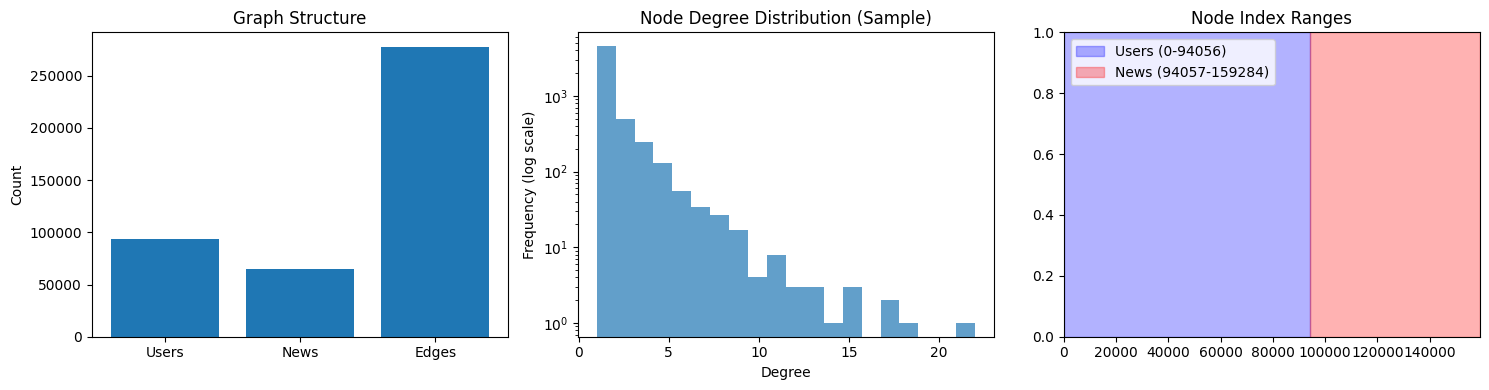

Graph Statistics:
  Total nodes: 159,285
  Total edges: 277,735
  Avg degree: 3.49


In [19]:
# New cell: Visualize graph structure
def visualize_graph_stats(edge_index, num_users, num_news):
    """Quick visualization of graph statistics"""
    total_edges = edge_index.shape[1]
    unique_edges = total_edges // 2  # Bidirectional
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Graph structure
    axes[0].bar(['Users', 'News', 'Edges'], [num_users, num_news, unique_edges])
    axes[0].set_title('Graph Structure')
    axes[0].set_ylabel('Count')
    
    # Node degree distribution (sample)
    from collections import Counter
    degrees = Counter(edge_index[0][:10000].numpy())  # Sample for speed
    degree_vals = list(degrees.values())
    
    axes[1].hist(degree_vals, bins=20, alpha=0.7)
    axes[1].set_title('Node Degree Distribution (Sample)')
    axes[1].set_xlabel('Degree')
    axes[1].set_ylabel('Frequency (log scale)')
    axes[1].set_yscale('log') ## this is given to visualize the end of long tail
    
    # User vs News node ranges
    axes[2].axvspan(0, num_users, alpha=0.3, color='blue', label=f'Users (0-{num_users-1})')
    axes[2].axvspan(num_users, num_users + num_news, alpha=0.3, color='red', label=f'News ({num_users}-{num_users + num_news-1})')
    axes[2].set_xlim(0, num_users + num_news)
    axes[2].set_title('Node Index Ranges')
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()
    
    print(f"Graph Statistics:")
    print(f"  Total nodes: {num_users + num_news:,}")
    print(f"  Total edges: {unique_edges:,}")
    print(f"  Avg degree: {2 * unique_edges / (num_users + num_news):.2f}")

# Visualize
visualize_graph_stats(train_edge_index, len(user_to_id), len(news_to_id))

**Comment:** Here we can see only a small number of users have contributed to high number of interactions.

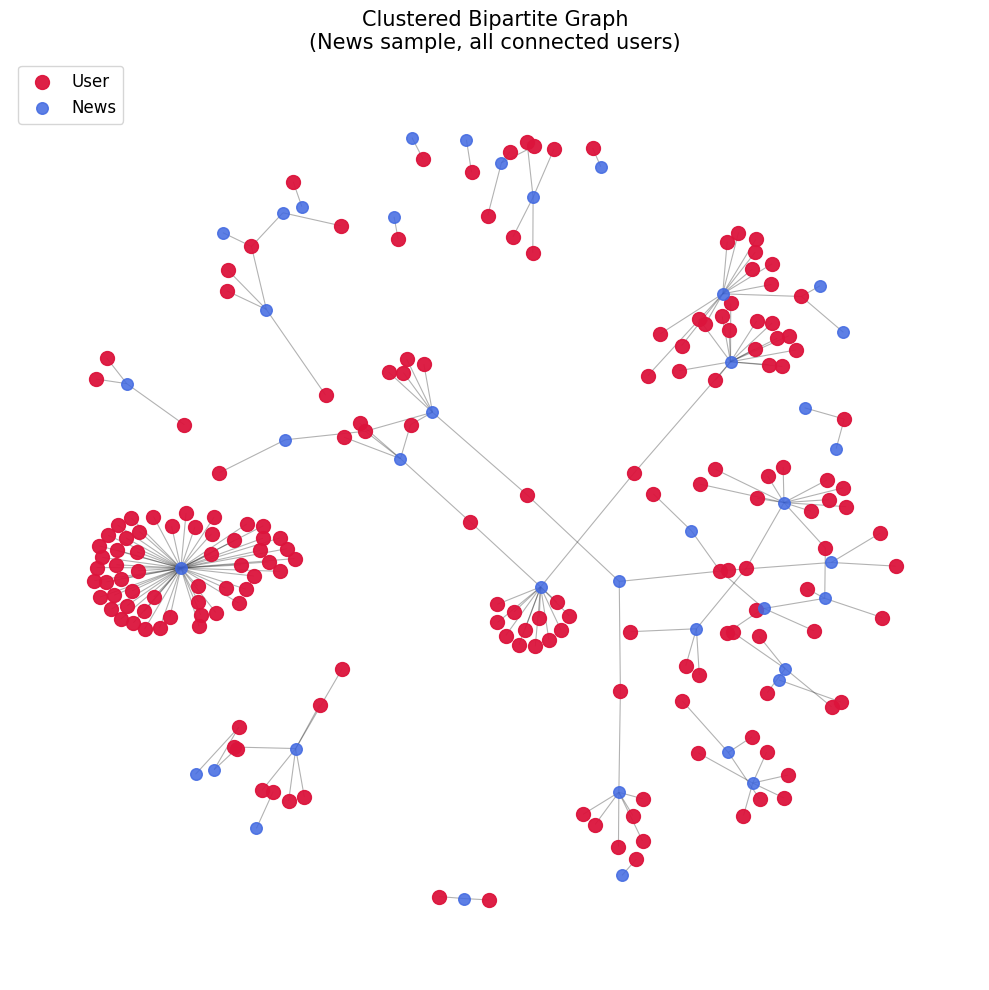

Visualization: 182 users, 40 news, 199 edges


In [20]:
def visualize_clustered_bipartite_with_legend(user_to_id, news_to_id, edge_index, news_sample=40, show_labels=False):
    user_indices_cpu = edge_index[0].cpu().numpy()
    news_indices_cpu = edge_index[1].cpu().numpy()
    
    # Sample news nodes
    unique_news = np.unique(news_indices_cpu)
    sampled_news = np.random.choice(unique_news, min(news_sample, len(unique_news)), replace=False)
    sampled_news_set = set(sampled_news)

    # Find all users connected to sampled news
    connected_users = set(user_indices_cpu[np.isin(news_indices_cpu, list(sampled_news_set))])
    
    # Build subgraph
    G = nx.Graph()
    user_id_to_name = {idx: uid for uid, idx in user_to_id.items()}
    news_id_to_name = {idx: nid for nid, idx in news_to_id.items()}
    for n_idx in sampled_news:
        news_name = news_id_to_name.get(n_idx, f"news_{n_idx}")
        G.add_node(f"n_{n_idx}", node_type='news', name=news_name)
    for u_idx in connected_users:
        user_name = user_id_to_name.get(u_idx, f"user_{u_idx}")
        G.add_node(f"u_{u_idx}", node_type='user', name=user_name)
    edge_count = 0
    for u_idx, n_idx in zip(user_indices_cpu, news_indices_cpu):
        if n_idx in sampled_news_set and u_idx in connected_users:
            G.add_edge(f"u_{u_idx}", f"n_{n_idx}")
            edge_count += 1

    pos = nx.spring_layout(G, k=0.5, iterations=200, seed=42)
    user_nodes = [n for n in G.nodes if G.nodes[n]['node_type'] == 'user']
    news_nodes = [n for n in G.nodes if G.nodes[n]['node_type'] == 'news']

    plt.figure(figsize=(10, 10))

    # Draw nodes
    user_scatter = nx.draw_networkx_nodes(G, pos, nodelist=user_nodes, node_color='crimson', node_size=100, alpha=0.95, label='User')
    news_scatter = nx.draw_networkx_nodes(G, pos, nodelist=news_nodes, node_color='royalblue', node_size=70, alpha=0.85, label='News')
    nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.8)

    # Draw labels if requested
    if show_labels:
        user_labels = {n: G.nodes[n]['name'] for n in user_nodes}
        news_labels = {n: G.nodes[n]['name'] for n in news_nodes}
        nx.draw_networkx_labels(G, pos, labels=user_labels, font_size=8, font_color='black')
        nx.draw_networkx_labels(G, pos, labels=news_labels, font_size=8, font_color='gray')

    # Add legend
    plt.legend([user_scatter, news_scatter], ['User', 'News'], scatterpoints=1, loc='upper left', fontsize=12)
    plt.title("Clustered Bipartite Graph\n(News sample, all connected users)", fontsize=15)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    print(f"Visualization: {len(user_nodes)} users, {len(news_nodes)} news, {edge_count} edges")

# Usage example
visualize_clustered_bipartite_with_legend(user_to_id, news_to_id, train_edge_index, news_sample=40, show_labels=False)

# 3: Simple Model

## 3.1: Unified GNN Class

In [21]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, SAGEConv, LGConv
from torch.nn import ModuleList

class UnifiedGNN(nn.Module):
    """Unified GNN supporting SAGE, GAT, and LightGCN"""
    
    def __init__(self, num_users, num_news, hidden_dim=32, num_layers=2, 
                 conv_type="GAT", dropout=0.2, heads=4):
        super().__init__()
        
        self.num_users = num_users
        self.num_news = num_news
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.conv_type = conv_type
        self.dropout = dropout
        
        # Embeddings for all nodes
        total_nodes = num_users + num_news
        self.embedding = nn.Embedding(total_nodes, hidden_dim)
        
        # Different conv layers based on type
        if conv_type == "SAGE":
            self.convs = ModuleList([
                SAGEConv(hidden_dim, hidden_dim) 
                for _ in range(num_layers)
            ])
        elif conv_type == "GAT":
            self.convs = ModuleList([
                GATConv(hidden_dim, hidden_dim, heads=heads, concat=False, 
                       dropout=dropout, add_self_loops=False) 
                for _ in range(num_layers)
            ])
        elif conv_type == "LG":
            self.convs = ModuleList([
                LGConv() for _ in range(num_layers)
            ])
            
        # Initialize embeddings
        nn.init.normal_(self.embedding.weight, std=0.1)
        
        # Dropout for regularization
        self.dropout_layer = nn.Dropout(dropout)
        
    def forward(self, edge_index):
        """Forward pass for bipartite graph"""
        x = self.embedding.weight  # [total_nodes, hidden_dim]
        
        if self.conv_type == "LG":
            # LightGCN: Store all layer outputs for final combination
            layer_embs = [x]  # Include initial embeddings
            
            for conv in self.convs:
                x = conv(x, edge_index)
                layer_embs.append(x)
            
            # LightGCN: Average all layers (including initial)
            final_emb = torch.mean(torch.stack(layer_embs), dim=0)
            
        else:
            # SAGE/GAT: Standard message passing with activations
            for i, conv in enumerate(self.convs):
                x = conv(x, edge_index)
                if i < len(self.convs) - 1:  # No activation on last layer
                    x = F.relu(x)
                    x = self.dropout_layer(x)
            final_emb = x
            
        return self.embedding.weight, final_emb
    
    def get_user_news_embeddings(self, final_emb):
        """Split embeddings into users and news"""
        user_emb = final_emb[:self.num_users]
        news_emb = final_emb[self.num_users:]
        return user_emb, news_emb

# Test all three models
def create_model(conv_type, **kwargs):
    """Factory function to create different GNN models"""
    return UnifiedGNN(
        num_users=len(user_to_id),
        num_news=len(news_to_id),
        hidden_dim=32,  # Reduced from 64
        num_layers=2,   # Reduced from 3  
        conv_type=conv_type,
        dropout=0.3,    # Increased dropout
        **kwargs
    )

# Create all three models
device = 'cuda' if torch.cuda.is_available() else 'cpu'
models = {
    "GAT": create_model("GAT", heads=4),
    "SAGE": create_model("SAGE"), 
    "LightGCN": create_model("LG")
}

for name, model in models.items():
    model = model.to(device)
    params = sum(p.numel() for p in model.parameters())
    print(f"{name}: {params:,} parameters")

/usr/local/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GAT: 5,105,888 parameters
SAGE: 5,101,280 parameters
LightGCN: 5,097,120 parameters


## 3.2: BPR training data and loss

For our loss, used Bayesian Personalized Ranking (BPR) to optimize the objective. **BPR generates a personalized recommendation for each user by encouraging the scores of rooted positive edges to be higher than those of negative edges.** This approach encourages the model to prioritize positively ranked articles more highly than negatively ranked ones, effectively distinguishing between good and bad recommendations for a specific user. Since we are not mainly focused on link prediction (a classification problem), binary cross entropy loss was not employed.

Note: There is a distinction of information in the graph vs. the training data.
* Graph structure only contains positive edges (user clicked news)
* Training data: Contains explicit negative samples for BPR loss comparison

In [23]:
# Create validation triplets
import random
import os
from collections import defaultdict

def create_bpr_training_data(behaviors_df, user_to_id, news_to_id, split='train', neg_ratio=1, seed=42):
    """
    Vectorized creation of BPR training triplets from behaviors DataFrame.
    Returns a numpy array of shape (n_triplets, 3): (user_idx, pos_item_idx, neg_item_idx)
    """
    np.random.seed(seed)
    split_df = behaviors_df[behaviors_df['split'] == split].copy()
    
    # Flatten impressions into a DataFrame
    records = []
    for i, row in split_df.iterrows():
        user_id = row['user_id']
        if user_id not in user_to_id:
            continue
        user_idx = user_to_id[user_id]
        for news_id, label in row['impressions']:
            if news_id in news_to_id:
                news_idx = news_to_id[news_id]
                records.append((user_idx, news_idx, label))
    
    df = pd.DataFrame(records, columns=['user', 'news', 'label'])
    
    # Get positive and negative sets for each user
    user_pos = df[df['label']==1].groupby('user')['news'].apply(set).to_dict()
    user_neg = df[df['label']==0].groupby('user')['news'].apply(set).to_dict()
    all_news = np.arange(len(news_to_id))
    
    triplets = []
    for user, pos_items in user_pos.items():
        neg_candidates = np.array(list(user_neg.get(user, set()) | (set(all_news) - pos_items)))
        pos_items_arr = np.array(list(pos_items))
        if len(neg_candidates) == 0:
            continue  # skip if user has no negatives
        for pos_item in pos_items_arr:
            # Vectorized negative sampling: fast, can repeat for neg_ratio
            neg_samples = np.random.choice(neg_candidates, size=neg_ratio, replace=(len(neg_candidates)<neg_ratio))
            for neg_item in neg_samples:
                triplets.append((user, pos_item, neg_item))
    
    print(f"Created {len(triplets)} triplets for {split} (vectorized)")
    return np.array(triplets, dtype=np.int32)
    return triplets

def load_or_create_bpr_triplets(behaviors_df, user_to_id, news_to_id, split, neg_ratio=1, seed=42):
    out_dir = 'data/bpr_loss_triplets'
    os.makedirs(out_dir, exist_ok=True)
    out_path = f"{out_dir}/{split}_triplets.npy"
    
    if os.path.exists(out_path):
        print(f"Loading cached {split} triplets from {out_path}")
        triplets = np.load(out_path)
        return triplets
    
    print(f"No cache for {split} triplets. Calculating...")
    triplets = create_bpr_training_data(behaviors_df, user_to_id, news_to_id, split, neg_ratio, seed)
    np.save(out_path, triplets)
    print(f"Saved {split} triplets to {out_path}")
    return triplets

# Usage:
train_triplets = load_or_create_bpr_triplets(behaviors_df, user_to_id, news_to_id, 'train', neg_ratio=1)
val_triplets = load_or_create_bpr_triplets(behaviors_df, user_to_id, news_to_id, 'val', neg_ratio=1)

Loading cached train triplets from data/bpr_loss_triplets/train_triplets.npy
Loading cached val triplets from data/bpr_loss_triplets/val_triplets.npy


In [24]:
train_triplets[0]

array([    0, 11153,  2449], dtype=int32)

What Each Triplet Means: `(user_123, news_456, news_789)` means:
* User 123 clicked on News 456 (positive interaction)
* User 123 did NOT click on News 789 (negative interaction)
* Training signal: User 123 prefers News 456 over News 789
* During training, the loss function tries to maximize: `sigmoid(score(user_123, news_456) - score(user_123, news_789))`
* So have two types of negative samples: 1. Explicit negatives (users saw but did not click) and 2. Implicit Negatives (users never saw)

This approach was adopted as an improvement of random negative sampling that we saw in an implementation.

In [25]:
print(type(train_triplets))
# If <class 'set'> or <class 'dict'>, wrap with list() for random.sample

<class 'numpy.ndarray'>


In [26]:
# BPR Loss function
def compute_bpr_loss(user_emb, news_emb, triplets_batch, reg_lambda=1e-4):
    """Compute BPR loss for a batch of triplets"""
    users, pos_items, neg_items = triplets_batch
    
    # Get embeddings
    u_emb = user_emb[users]                    # [batch, emb_dim]
    pos_emb = news_emb[pos_items]              # [batch, emb_dim]  
    neg_emb = news_emb[neg_items]              # [batch, emb_dim]
    
    # Compute scores
    pos_scores = torch.sum(u_emb * pos_emb, dim=1)  # [batch]
    neg_scores = torch.sum(u_emb * neg_emb, dim=1)  # [batch]
    
    # BPR loss: maximize pos_score - neg_score
    bpr_loss = torch.mean(F.softplus(-(pos_scores - neg_scores)))
    
    # L2 regularization  
    reg_loss = reg_lambda * (u_emb.norm(2).pow(2) + pos_emb.norm(2).pow(2) + neg_emb.norm(2).pow(2)) / len(users)
    
    return bpr_loss + reg_loss, bpr_loss, reg_loss

# Test BPR loss
batch_size = 1024
sample_batch = random.sample(list(train_triplets), min(batch_size, len(train_triplets)))
users, pos_items, neg_items = zip(*sample_batch)

users = torch.tensor(users, device=device)
pos_items = torch.tensor(pos_items, device=device) 
neg_items = torch.tensor(neg_items, device=device)
train_edge_index = train_edge_index.to(device)

# Test loss computation
model.eval()
with torch.no_grad():
    _, final_emb = model(train_edge_index)
    user_emb, news_emb = model.get_user_news_embeddings(final_emb)
    
    total_loss, bpr_loss, reg_loss = compute_bpr_loss(user_emb, news_emb, (users, pos_items, neg_items))
    print(f"Sample loss - Total: {total_loss:.4f}, BPR: {bpr_loss:.4f}, Reg: {reg_loss:.4f}")

Sample loss - Total: 0.6910, BPR: 0.6910, Reg: 0.0000


## 3.3: Training Loop

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

def create_data_loader(triplets, batch_size=1024):
    """Convert triplets to DataLoader"""
    users = torch.tensor([t[0] for t in triplets], dtype=torch.long)
    pos_items = torch.tensor([t[1] for t in triplets], dtype=torch.long) 
    neg_items = torch.tensor([t[2] for t in triplets], dtype=torch.long)
    
    dataset = TensorDataset(users, pos_items, neg_items)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True)

def bpr_loss(user_emb, pos_emb, neg_emb):
    """BPR loss function"""
    pos_scores = (user_emb * pos_emb).sum(dim=1)
    neg_scores = (user_emb * neg_emb).sum(dim=1)
    loss = -torch.log(torch.sigmoid(pos_scores - neg_scores)).mean()
    return loss

def train_epoch(model, train_loader, optimizer, edge_index, device):
    """Train for one epoch - FIXED: Get fresh embeddings for each batch"""
    model.train()
    total_loss = 0
    num_batches = 0
    
    for users, pos_items, neg_items in train_loader:
        users, pos_items, neg_items = users.to(device), pos_items.to(device), neg_items.to(device)
        
        optimizer.zero_grad()
        
        # FIXED: Get fresh embeddings for each batch
        _, final_emb = model(edge_index)
        user_emb, news_emb = model.get_user_news_embeddings(final_emb)
        
        # Get embeddings for batch
        batch_user_emb = user_emb[users]
        batch_pos_emb = news_emb[pos_items] 
        batch_neg_emb = news_emb[neg_items]
        
        # Compute loss
        loss = bpr_loss(batch_user_emb, batch_pos_emb, batch_neg_emb)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
    
    return total_loss / num_batches

def validate(model, val_loader, edge_index, device):
    """Validate model"""
    model.eval()
    total_loss = 0
    num_batches = 0
    
    with torch.no_grad():
        for users, pos_items, neg_items in val_loader:
            users, pos_items, neg_items = users.to(device), pos_items.to(device), neg_items.to(device)
            
            # Get fresh embeddings
            _, final_emb = model(edge_index)
            user_emb, news_emb = model.get_user_news_embeddings(final_emb)
            
            batch_user_emb = user_emb[users]
            batch_pos_emb = news_emb[pos_items]
            batch_neg_emb = news_emb[neg_items]
            
            loss = bpr_loss(batch_user_emb, batch_pos_emb, batch_neg_emb)
            total_loss += loss.item()
            num_batches += 1
    
    return total_loss / num_batches

def train_model(model, train_triplets, val_triplets, edge_index, 
                epochs=50, lr=0.001, weight_decay=1e-4, patience=5):
    """Main training function with early stopping"""
    
    device = next(model.parameters()).device
    edge_index = edge_index.to(device)
    
    # Create data loaders
    train_loader = create_data_loader(train_triplets, batch_size=1024)
    val_loader = create_data_loader(val_triplets, batch_size=1024)
    
    # Optimizer with weight decay (L2 regularization)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # Early stopping variables
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    # Track losses
    train_losses = []
    val_losses = []
    
    print(f"Starting training for {epochs} epochs...")
    print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")
    
    for epoch in range(epochs):
        # Train
        train_loss = train_epoch(model, train_loader, optimizer, edge_index, device)
        
        # Validate  
        val_loss = validate(model, val_loader, edge_index, device)
        
        # Track losses
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        
        print(f"Epoch {epoch+1:2d}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
        
        # Early stopping check
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_model_state = model.state_dict().copy()
            print(f"         → New best validation loss!")
        else:
            patience_counter += 1
            print(f"         → No improvement ({patience_counter}/{patience})")
            
        if patience_counter >= patience:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Loaded best model (val loss: {best_val_loss:.4f})")
    
    return train_losses, val_losses

def plot_training_curves(train_losses, val_losses, title="Training Curves"):
    """Plot training and validation losses"""
    plt.figure(figsize=(10, 6))
    plt.plot(train_losses, label='Train Loss', marker='o', markersize=3)
    plt.plot(val_losses, label='Val Loss', marker='s', markersize=3)
    plt.xlabel('Epoch')
    plt.ylabel('BPR Loss')
    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"Final - Train: {train_losses[-1]:.4f}, Val: {val_losses[-1]:.4f}")

Starting training for 30 epochs...
Train batches: 270, Val batches: 35
Epoch  1: Train Loss: 0.2514, Val Loss: 0.2782
         → New best validation loss!
Epoch  2: Train Loss: 0.0443, Val Loss: 0.2656
         → New best validation loss!
Epoch  3: Train Loss: 0.0370, Val Loss: 0.2577
         → New best validation loss!
Epoch  4: Train Loss: 0.0333, Val Loss: 0.2507
         → New best validation loss!
Epoch  5: Train Loss: 0.0300, Val Loss: 0.2442
         → New best validation loss!
Epoch  6: Train Loss: 0.0287, Val Loss: 0.2382
         → New best validation loss!
Epoch  7: Train Loss: 0.0278, Val Loss: 0.2426
         → No improvement (1/5)
Epoch  8: Train Loss: 0.0267, Val Loss: 0.2378
         → New best validation loss!
Epoch  9: Train Loss: 0.0264, Val Loss: 0.2402
         → No improvement (1/5)
Epoch 10: Train Loss: 0.0260, Val Loss: 0.2351
         → New best validation loss!
Epoch 11: Train Loss: 0.0253, Val Loss: 0.2280
         → New best validation loss!
Epoch 12: Train

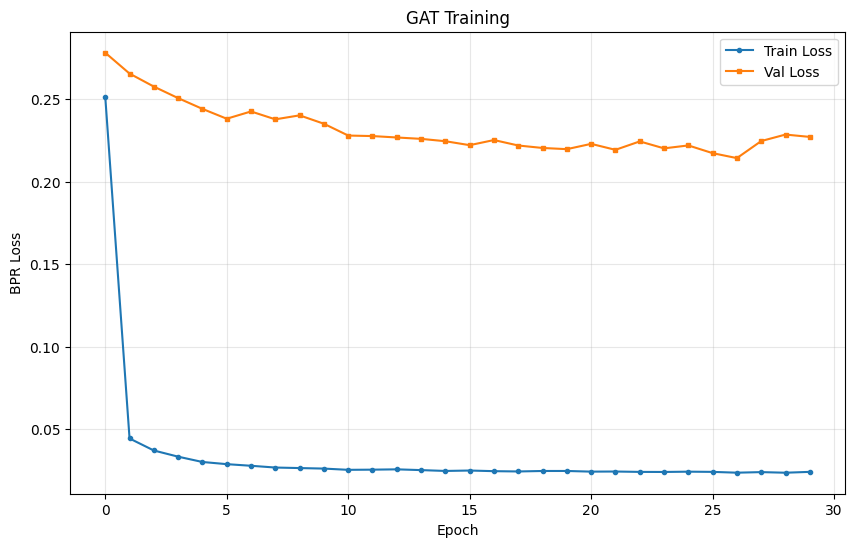

Final - Train: 0.0241, Val: 0.2272


In [28]:
model_gat = models["GAT"].to(device)  # Choose GAT, SAGE, or LightGCN

train_losses, val_losses = train_model(
    model=model_gat,
    train_triplets=train_triplets,
    val_triplets=val_triplets, 
    edge_index=train_edge_index,
    epochs=30,           # Reduced epochs
    lr=0.0005,           # Learning rate
    weight_decay=1e-4,  # L2 regularization  
    patience=5          # Early stopping patience
)

plot_training_curves(train_losses, val_losses, "GAT Training")

Starting training for 30 epochs...
Train batches: 270, Val batches: 35
Epoch  1: Train Loss: 0.1657, Val Loss: 0.2469
         → New best validation loss!
Epoch  2: Train Loss: 0.0291, Val Loss: 0.2532
         → No improvement (1/5)
Epoch  3: Train Loss: 0.0241, Val Loss: 0.2548
         → No improvement (2/5)
Epoch  4: Train Loss: 0.0222, Val Loss: 0.2543
         → No improvement (3/5)
Epoch  5: Train Loss: 0.0210, Val Loss: 0.2618
         → No improvement (4/5)
Epoch  6: Train Loss: 0.0206, Val Loss: 0.2646
         → No improvement (5/5)
Early stopping triggered after 6 epochs
Loaded best model (val loss: 0.2469)


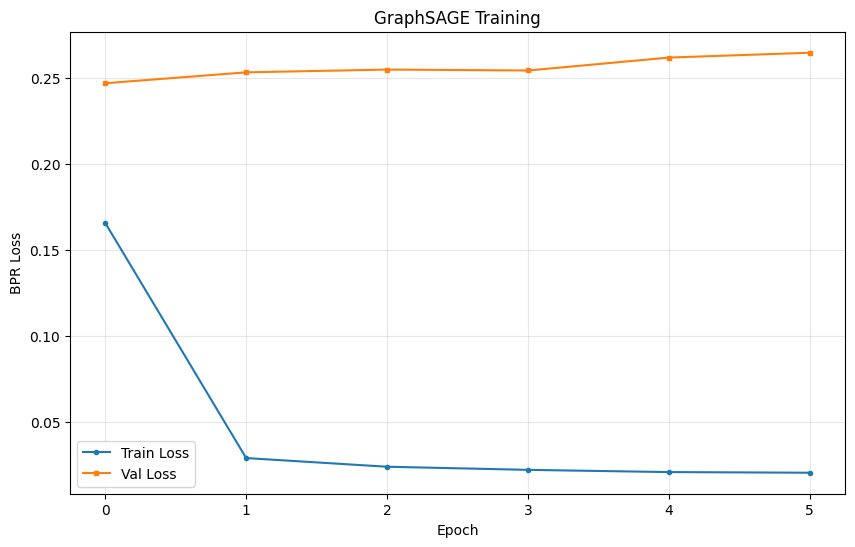

Final - Train: 0.0206, Val: 0.2646


In [29]:
model_sage = models["SAGE"].to(device)  # Choose GAT, SAGE, or LightGCN

train_losses, val_losses = train_model(
    model=model_sage,
    train_triplets=train_triplets,
    val_triplets=val_triplets, 
    edge_index=train_edge_index,
    epochs=30,           # Reduced epochs
    lr=0.0005,           # Learning rate
    weight_decay=1e-4,  # L2 regularization  
    patience=5          # Early stopping patience
)

plot_training_curves(train_losses, val_losses, "GraphSAGE Training")

Starting training for 30 epochs...
Train batches: 270, Val batches: 35
Epoch  1: Train Loss: 0.6923, Val Loss: 0.6931
         → New best validation loss!
Epoch  2: Train Loss: 0.6930, Val Loss: 0.6931
         → New best validation loss!
Epoch  3: Train Loss: 0.6930, Val Loss: 0.6931
         → New best validation loss!
Epoch  4: Train Loss: 0.6928, Val Loss: 0.6931
         → New best validation loss!
Epoch  5: Train Loss: 0.6922, Val Loss: 0.6930
         → New best validation loss!
Epoch  6: Train Loss: 0.6901, Val Loss: 0.6926
         → New best validation loss!
Epoch  7: Train Loss: 0.6845, Val Loss: 0.6916
         → New best validation loss!
Epoch  8: Train Loss: 0.6749, Val Loss: 0.6902
         → New best validation loss!
Epoch  9: Train Loss: 0.6643, Val Loss: 0.6887
         → New best validation loss!
Epoch 10: Train Loss: 0.6563, Val Loss: 0.6877
         → New best validation loss!
Epoch 11: Train Loss: 0.6506, Val Loss: 0.6869
         → New best validation loss!
Epoch

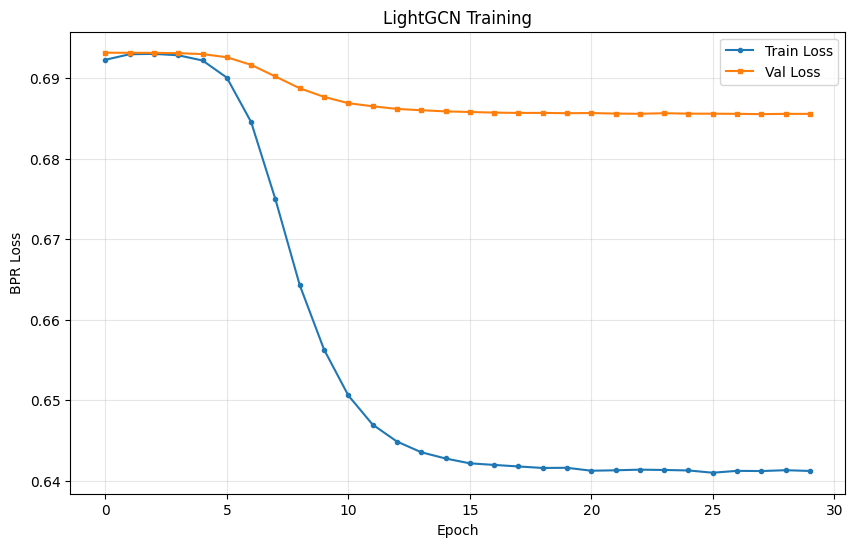

Final - Train: 0.6412, Val: 0.6856


In [30]:
model_lightgcn = models["LightGCN"].to(device)  # Choose GAT, SAGE, or LightGCN

train_losses, val_losses = train_model(
    model=model_lightgcn,
    train_triplets=train_triplets,
    val_triplets=val_triplets, 
    edge_index=train_edge_index,
    epochs=30,           # Reduced epochs
    lr=0.0005,           # Learning rate
    weight_decay=1e-4,  # L2 regularization  
    patience=5          # Early stopping patience
)

plot_training_curves(train_losses, val_losses, "LightGCN Training")

## 3.4: Visualization of Embeddings

In [31]:
# Create fresh model (same architecture, but untrained)
fresh_model = UnifiedGNN(
    num_users=len(user_to_id),
    num_news=len(news_to_id),
    hidden_dim=32,
    num_layers=2,
    conv_type="SAGE",  # Match your trained model
    dropout=0.3,
    heads=4
).to(device)

print("Fresh model created with random weights")
print(f"Fresh model parameters: {sum(p.numel() for p in fresh_model.parameters()):,}")

Fresh model created with random weights
Fresh model parameters: 5,101,280


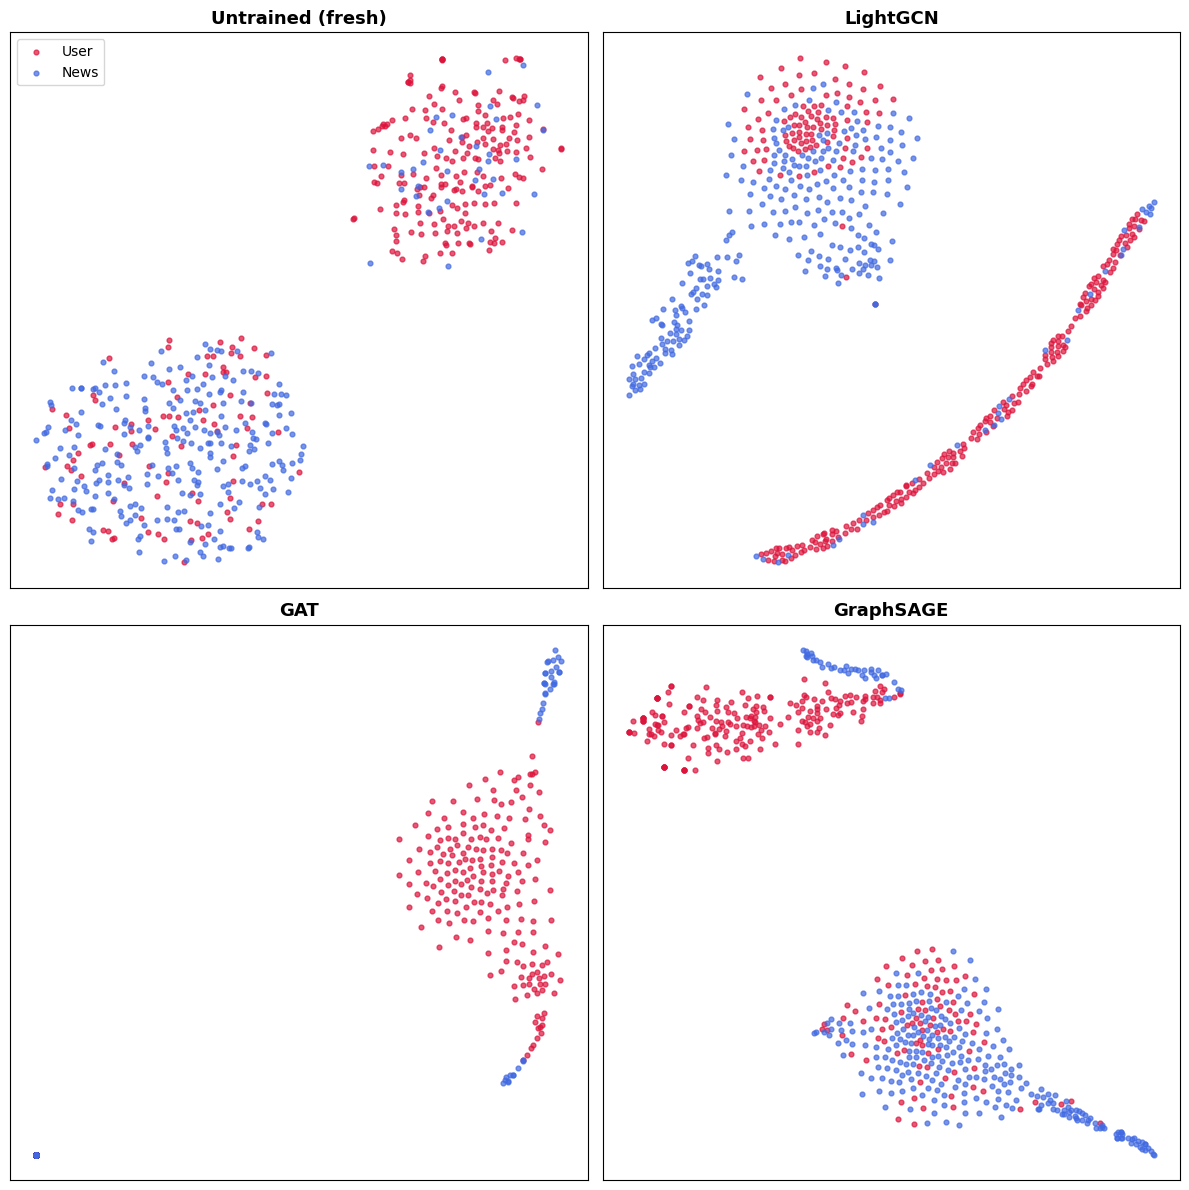

In [32]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
import numpy as np
import torch

# -- Sampling parameters --
num_users = len(user_to_id)
num_news = len(news_to_id)
sample_users = 300  # Sample 300 users
sample_news = 300   # Sample 300 news

user_indices = np.random.choice(num_users, size=sample_users, replace=False)
news_indices = np.random.choice(num_news, size=sample_news, replace=False)

# Prepare indices for all nodes (concatenate users and news for each model)
sampled_indices = np.concatenate([user_indices, num_users + news_indices])

# Rebuild models and collect embeddings as before...
model_names = ["Untrained (fresh)", "LightGCN", "GAT", "GraphSAGE"]
models = [fresh_model, model_lightgcn, model_gat, model_sage]
embeddings_list = []

for m in models:
    m.eval()
    with torch.no_grad():
        _, node_emb = m(train_edge_index)
        node_emb_np = node_emb.cpu().numpy()
        # Only keep the sampled nodes
        embeddings_list.append(node_emb_np[sampled_indices])

# Stack embeddings for joint t-SNE
all_embeddings = np.vstack(embeddings_list)

# Use PCA before t-SNE for more speed (highly recommended)
pca = PCA(n_components=32, random_state=42)
all_embeddings_pca = pca.fit_transform(all_embeddings)

tsne = TSNE(n_components=2, random_state=42, perplexity=30, metric='cosine')
tsne_all = tsne.fit_transform(all_embeddings_pca)

split_points = np.cumsum([emb.shape[0] for emb in embeddings_list])
tsne_embeddings = np.split(tsne_all, split_points[:-1])

# 2x2 grid plot
fig, axes = plt.subplots(2, 2, figsize=(12, 12))
axes = axes.flatten()
sample_total = sample_users + sample_news

for idx, ax in enumerate(axes):
    ax.scatter(tsne_embeddings[idx][:sample_users, 0], tsne_embeddings[idx][:sample_users, 1], 
               c='crimson', label='User', alpha=0.7, s=12)
    ax.scatter(tsne_embeddings[idx][sample_users:, 0], tsne_embeddings[idx][sample_users:, 1], 
               c='royalblue', label='News', alpha=0.7, s=12)
    ax.set_title(model_names[idx], fontsize=13, fontweight='bold')
    ax.set_xticks([]); ax.set_yticks([])
    if idx == 0:
        ax.legend(loc='best')

plt.tight_layout()
plt.show()

### 3.4.1: Embedding Quality

=== Embedding Quality Comparison ===
Model           | User-User       | News-News       | Pos             | Neg             | Improve  
-------------------------------------------------------------------------------------
Untrained (fresh) | 0.241±0.059 | 0.181±0.061 | 0.178±0.047 | 0.255±0.043 | 0.076
LightGCN        | 0.048±0.042 | 0.026±0.075 | 0.864±0.973 | 0.119±0.083 | -0.746
GAT             | 0.396±0.514 | 0.401±0.695 | 1.376±0.469 | 0.999±0.255 | -0.376
GraphSAGE       | 1.499±1.222 | 0.606±1.025 | 0.807±0.416 | 2.557±0.825 | 1.750


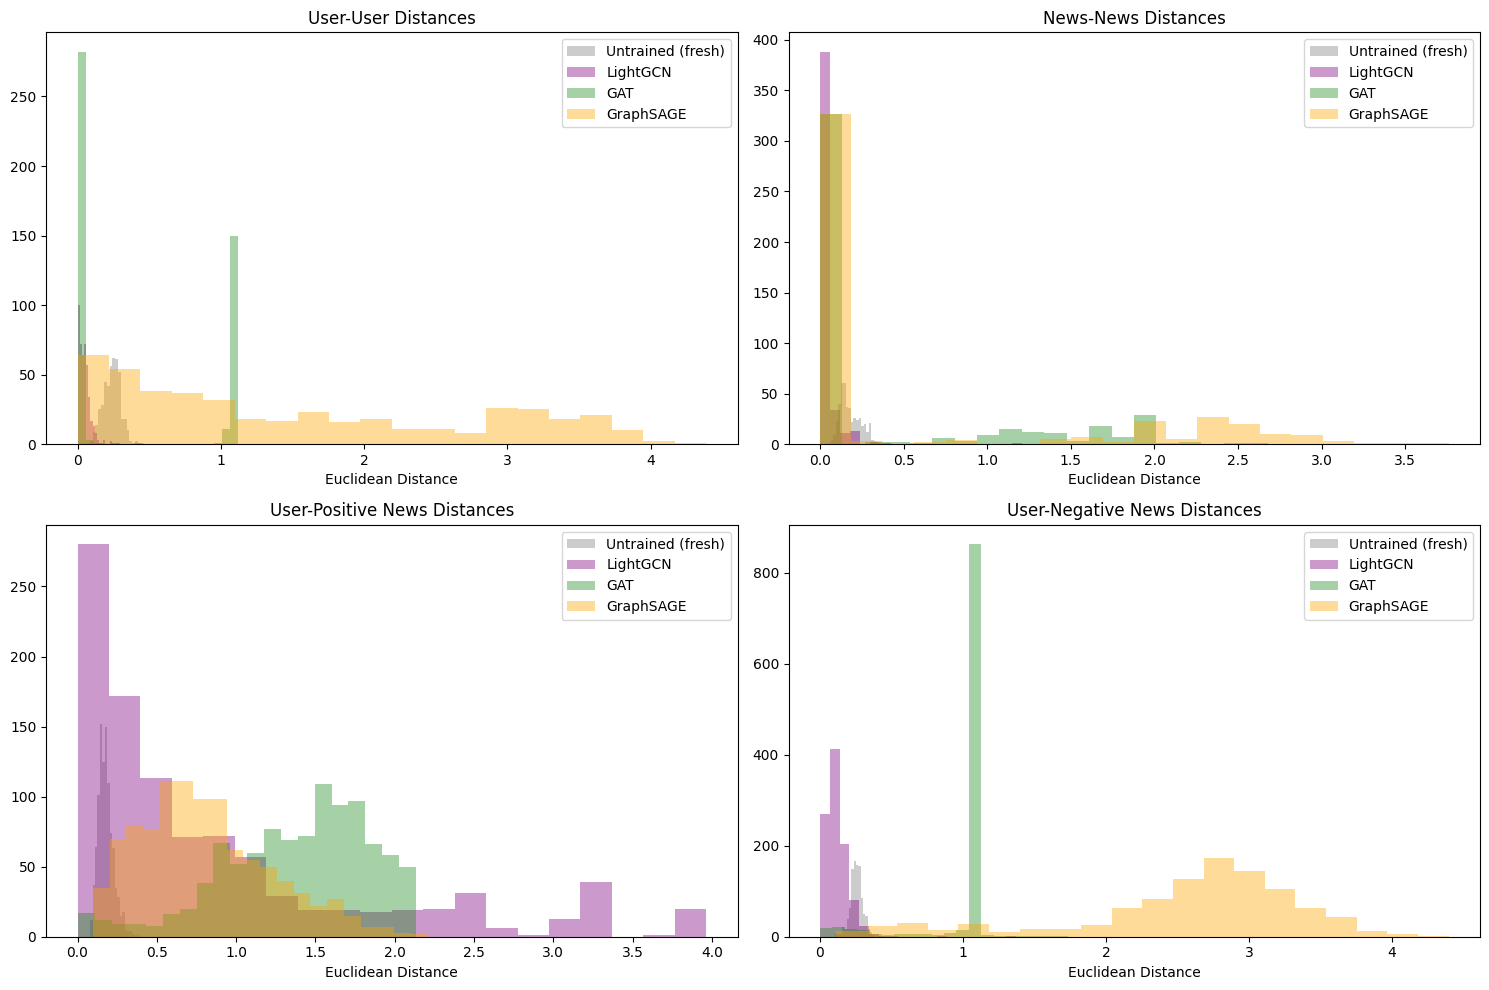

/tmp/ipykernel_1379634/2039370917.py:122: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=box_labels, patch_artist=True)


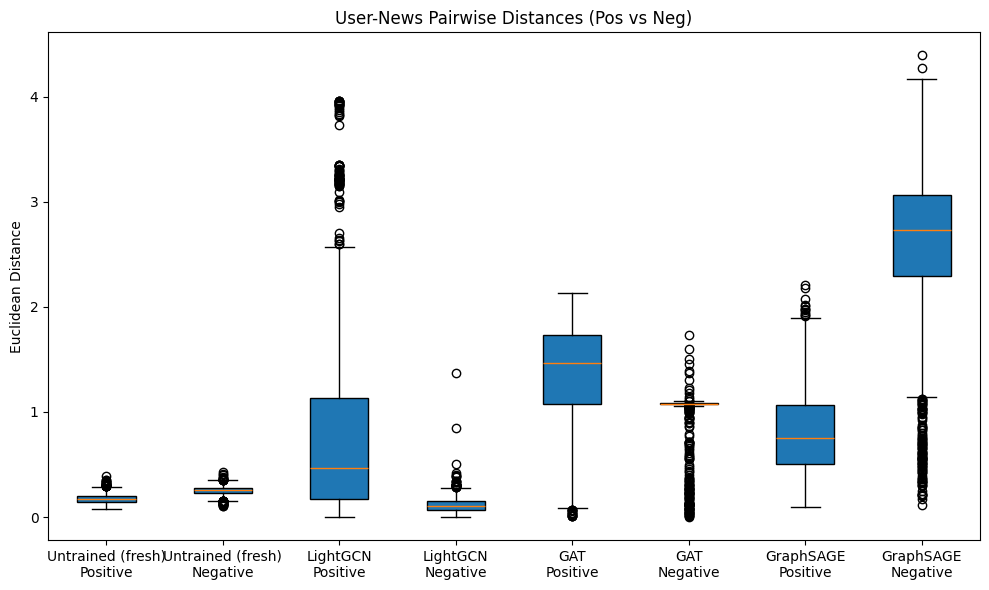

In [33]:
import matplotlib.pyplot as plt
import numpy as np
import random

def analyze_embedding_quality_multi(models, model_names, edge_index, train_triplets, sample_size=1000):
    """Compare embedding quality across multiple models"""

    results = []
    plot_data = {'user_dists': [], 'news_dists': [], 'pos_pairs': [], 'neg_pairs': []}

    for model in models:
        model.eval()
        with torch.no_grad():
            _, final_emb = model(edge_index)
            user_emb, news_emb = model.get_user_news_embeddings(final_emb)

        # Sampling
        user_sample = user_emb[:sample_size//2].cpu().numpy()
        news_sample = news_emb[:sample_size//2].cpu().numpy()

        # User-user distances
        user_dists = []
        for i in range(0, len(user_sample), 10):
            for j in range(i+1, min(i+10, len(user_sample))):
                dist = np.linalg.norm(user_sample[i] - user_sample[j])
                user_dists.append(dist)

        # News-news distances
        news_dists = []
        for i in range(0, len(news_sample), 10):
            for j in range(i+1, min(i+10, len(news_sample))):
                dist = np.linalg.norm(news_sample[i] - news_sample[j])
                news_dists.append(dist)

        # User-news distances (positive vs negative pairs)
        pos_pairs = []
        neg_pairs = []
        sample_triplets = random.sample(list(train_triplets), min(1000, len(train_triplets)))

        for user_idx, pos_news, neg_news in sample_triplets:
            if user_idx < len(user_emb) and pos_news < len(news_emb) and neg_news < len(news_emb):
                user_vec = user_emb[user_idx].cpu().numpy()
                pos_vec = news_emb[pos_news].cpu().numpy()
                neg_vec = news_emb[neg_news].cpu().numpy()
                pos_dist = np.linalg.norm(user_vec - pos_vec)
                neg_dist = np.linalg.norm(user_vec - neg_vec)
                pos_pairs.append(pos_dist)
                neg_pairs.append(neg_dist)

        # Store stats for reporting
        result = {
            'user_mean': np.mean(user_dists),
            'user_std': np.std(user_dists),
            'news_mean': np.mean(news_dists),
            'news_std': np.std(news_dists),
            'pos_mean': np.mean(pos_pairs),
            'pos_std': np.std(pos_pairs),
            'neg_mean': np.mean(neg_pairs),
            'neg_std': np.std(neg_pairs),
            'improvement': np.mean(neg_pairs) - np.mean(pos_pairs),
        }
        results.append(result)
        plot_data['user_dists'].append(user_dists)
        plot_data['news_dists'].append(news_dists)
        plot_data['pos_pairs'].append(pos_pairs)
        plot_data['neg_pairs'].append(neg_pairs)

    # Print comparison table
    print("=== Embedding Quality Comparison ===")
    print(f"{'Model':<15} | {'User-User':<15} | {'News-News':<15} | {'Pos':<15} | {'Neg':<15} | {'Improve':<9}")
    print("-"*85)
    for i, name in enumerate(model_names):
        r = results[i]
        print(f"{name:<15} | {r['user_mean']:.3f}±{r['user_std']:.3f} | {r['news_mean']:.3f}±{r['news_std']:.3f} | "
              f"{r['pos_mean']:.3f}±{r['pos_std']:.3f} | {r['neg_mean']:.3f}±{r['neg_std']:.3f} | {r['improvement']:.3f}")

    # Overlayed plots for direct comparison
    colors = ['gray', 'purple', 'forestgreen', 'orange']  # add more if needed

    plt.figure(figsize=(15, 10))

    plt.subplot(2, 2, 1)
    for i, name in enumerate(model_names):
        plt.hist(plot_data['user_dists'][i], bins=20, alpha=0.4, label=f'{name}', color=colors[i])
    plt.title('User-User Distances')
    plt.xlabel('Euclidean Distance')
    plt.legend()

    plt.subplot(2, 2, 2)
    for i, name in enumerate(model_names):
        plt.hist(plot_data['news_dists'][i], bins=20, alpha=0.4, label=f'{name}', color=colors[i])
    plt.title('News-News Distances')
    plt.xlabel('Euclidean Distance')
    plt.legend()

    plt.subplot(2, 2, 3)
    for i, name in enumerate(model_names):
        plt.hist(plot_data['pos_pairs'][i], bins=20, alpha=0.4, label=f'{name}', color=colors[i])
    plt.title('User-Positive News Distances')
    plt.xlabel('Euclidean Distance')
    plt.legend()

    plt.subplot(2, 2, 4)
    for i, name in enumerate(model_names):
        plt.hist(plot_data['neg_pairs'][i], bins=20, alpha=0.4, label=f'{name}', color=colors[i])
    plt.title('User-Negative News Distances')
    plt.xlabel('Euclidean Distance')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Boxplot for positive vs negative pairs across models
    plt.figure(figsize=(10, 6))
    box_data = []
    box_labels = []
    for i, name in enumerate(model_names):
        box_data.append(plot_data['pos_pairs'][i])
        box_labels.append(f"{name}\nPositive")
        box_data.append(plot_data['neg_pairs'][i])
        box_labels.append(f"{name}\nNegative")
    plt.boxplot(box_data, labels=box_labels, patch_artist=True)
    plt.title('User-News Pairwise Distances (Pos vs Neg)')
    plt.ylabel('Euclidean Distance')
    plt.tight_layout()
    plt.show()

# Usage example:
models_list = [fresh_model, model_lightgcn, model_gat, model_sage]
model_names = ["Untrained (fresh)", "LightGCN", "GAT", "GraphSAGE"]

analyze_embedding_quality_multi(
    models=models_list,
    model_names=model_names,
    edge_index=train_edge_index,
    train_triplets=train_triplets
)

# 4: Evaluation

In [34]:
# Create test data for evaluation
def create_test_data(behaviors_df, user_to_id, news_to_id, split='dev'):
    """Create test data with user-item interactions"""
    split_data = behaviors_df[behaviors_df['split'] == split]
    
    user_test_items = defaultdict(list)  # positive test items per user
    
    for _, row in split_data.iterrows():
        user_id = row['user_id']
        if user_id not in user_to_id:
            continue
        user_idx = user_to_id[user_id]
        
        for news_id, label in row['impressions']:
            if news_id in news_to_id and label == 1:  # Only positive items
                news_idx = news_to_id[news_id]
                user_test_items[user_idx].append(news_idx)
    
    print(f"Test users with positive items: {len(user_test_items)}")
    print(f"Avg test items per user: {np.mean([len(items) for items in user_test_items.values()]):.2f}")
    return user_test_items

# Create test data
test_data = create_test_data(behaviors_df, user_to_id, news_to_id, 'test')

Test users with positive items: 19099
Avg test items per user: 1.81


In [35]:
user, news_list = next(iter(test_data.items()))
print(f"user: {user}")
print(f"test news indices: {news_list}")

user: 47225
test news indices: [16447]


In [36]:
def build_test_graph_fixed(train_edge_index, test_behaviors, user_to_id, news_to_id):
    """
    Build test graph by adding test interactions to training graph
    This ensures test users/news get proper embeddings during evaluation
    """
    print("Building test graph with test interactions...")
    
    # Start with training edges
    test_edge_index = train_edge_index.clone()
    
    # Add test user -> news edges (for embedding computation, not for cheating)
    new_edges_u = []
    new_edges_n = []
    
    test_interactions_count = 0
    
    for _, row in test_behaviors.iterrows():
        if row['user_id'] in user_to_id:
            user_idx = user_to_id[row['user_id']]
            
            # Add ALL test interactions (both positive and negative) to graph structure
            # This helps compute better embeddings without leaking evaluation targets
            for news_id, label in row['impressions']:
                if news_id in news_to_id:
                    news_idx = news_to_id[news_id]
                    new_edges_u.extend([user_idx, news_idx + len(user_to_id)])  # Bidirectional
                    new_edges_n.extend([news_idx + len(user_to_id), user_idx])
                    test_interactions_count += 1
    
    if new_edges_u:
        new_edges = torch.tensor([new_edges_u, new_edges_n], dtype=torch.long, device=train_edge_index.device)
        test_edge_index = torch.cat([test_edge_index, new_edges], dim=1)
    
    print(f"Test graph: {test_edge_index.shape[1]} total edges (+{test_interactions_count*2} from test)")
    return test_edge_index

def create_proper_test_data(behaviors_df, user_to_id, news_to_id, split='test'):
    """
    Create test data properly - separating what we evaluate vs what we use for embedding
    """
    split_data = behaviors_df[behaviors_df['split'] == split]
    
    user_test_items = {}  # What we want to predict (evaluation targets)
    user_all_items = {}   # All items user interacted with (for embedding computation)
    
    for _, row in split_data.iterrows():
        user_id = row['user_id']
        if user_id not in user_to_id:
            continue
        user_idx = user_to_id[user_id]
        
        test_positives = []    # Only positive items for evaluation
        all_interactions = []  # All interactions for embedding
        
        for news_id, label in row['impressions']:
            if news_id in news_to_id:
                news_idx = news_to_id[news_id]
                all_interactions.append((news_idx, label))
                
                if label == 1:  # Only positive for evaluation targets
                    test_positives.append(news_idx)
        
        if test_positives:  # Only include users with positive items
            user_test_items[user_idx] = test_positives
            user_all_items[user_idx] = all_interactions
    
    print(f"Proper test data: {len(user_test_items)} users with positive items")
    print(f"Avg positive items per user: {np.mean([len(items) for items in user_test_items.values()]):.2f}")
    
    return user_test_items, user_all_items

def evaluate_model_with_test_graph(
    model,
    train_edge_index,
    test_behaviors,
    test_data,         # user_test_items: {user_idx: [positive_news_indices]}
    test_all_items,    # user_all_items: {user_idx: [(news_idx, label), ...]}
    train_triplets,
    user_to_id,
    news_to_id,
    k_values=[5, 10, 20]
):
    import numpy as np
    from collections import defaultdict
    from sklearn.metrics import roc_auc_score

    test_edge_index = build_test_graph_fixed(train_edge_index, test_behaviors, user_to_id, news_to_id)
    model.eval()
    with torch.no_grad():
        _, final_emb = model(test_edge_index)
        user_emb, news_emb = model.get_user_news_embeddings(final_emb)
    
    def dcg_at_k(relevances, k):
        relevances = np.array(relevances)[:k]
        if len(relevances) == 0:
            return 0.0
        return np.sum(relevances / np.log2(np.arange(2, len(relevances) + 2)))
    
    def ndcg_at_k(relevances, k):
        dcg = dcg_at_k(relevances, k)
        ideal_relevances = sorted(relevances, reverse=True)
        idcg = dcg_at_k(ideal_relevances, k)
        return dcg / idcg if idcg > 0 else 0.0

    def reciprocal_rank(relevances):
        for i, rel in enumerate(relevances):
            if rel > 0:
                return 1.0 / (i + 1)
        return 0.0

    train_interactions = defaultdict(set)
    for user_idx, pos_item, _ in train_triplets:
        train_interactions[user_idx].add(pos_item)
    
    all_precisions = {k: [] for k in k_values}
    all_recalls = {k: [] for k in k_values}
    all_ndcgs = {k: [] for k in k_values}
    all_mrrs = []
    all_scores = []
    all_labels = []
    valid_users = 0
    
    for user_idx, test_items in test_data.items():
        if user_idx not in test_all_items or len(test_items) == 0:
            continue
        impression = test_all_items[user_idx]   # list of (news_idx, label)
        impression_news = [news_idx for news_idx, _ in impression]
        impression_labels = [label for _, label in impression]
        if len(impression_news) == 0:
            continue
        valid_users += 1

        # Embeddings for impression set only
        user_vec = user_emb[user_idx]
        news_vecs = news_emb[impression_news]
        
        # Mask out training clicks (optional for impression eval, but sometimes used)
        for i, news_idx in enumerate(impression_news):
            if user_idx in train_interactions and news_idx in train_interactions[user_idx]:
                impression_labels[i] = 0  # don't count these as targets

        sims = torch.cosine_similarity(user_vec.unsqueeze(0), news_vecs).cpu().numpy()
        sorted_idx = np.argsort(-sims)
        ranked_labels = np.array(impression_labels)[sorted_idx]

        hits_k = lambda k: ranked_labels[:k].sum()
        n_rel = (np.array(impression_labels) == 1).sum()
        n_rel = max(1, n_rel)  # avoid div by zero

        for k in k_values:
            all_precisions[k].append(hits_k(k) / k)
            all_recalls[k].append(hits_k(k) / n_rel)
            all_ndcgs[k].append(ndcg_at_k(ranked_labels, k))
        all_mrrs.append(reciprocal_rank(ranked_labels))

        # For AUC
        all_scores.extend(list(sims))
        all_labels.extend(list(np.array(impression_labels)))

    results = {}
    results['valid_users'] = valid_users
    results['mrr'] = np.mean(all_mrrs) if all_mrrs else 0.0
    if len(set(all_labels)) > 1:
        try:
            results['auc'] = roc_auc_score(all_labels, all_scores)
        except Exception:
            results['auc'] = 0.0
    else:
        results['auc'] = 0.0
    for k in k_values:
        results[f'precision@{k}'] = np.mean(all_precisions[k]) if all_precisions[k] else 0.0
        results[f'recall@{k}'] = np.mean(all_recalls[k]) if all_recalls[k] else 0.0
        results[f'ndcg@{k}'] = np.mean(all_ndcgs[k]) if all_ndcgs[k] else 0.0
    return results

# Use:
test_behaviors = behaviors_df[behaviors_df['split'] == 'test'] # 
test_data_proper, test_all_items = create_proper_test_data(behaviors_df, user_to_id, news_to_id, 'test')

Proper test data: 19099 users with positive items
Avg positive items per user: 1.50


`test_data_proper = dict of {user_idx: [clicked_news_indices]}` (positives per user)

`test_all_items = dict of {user_idx: [(news_idx, label), ...]}` (impression set for each user, with label 1 if clicked, 0 otherwise)

In [37]:
results_gat = evaluate_model_with_test_graph(
    model=model_gat,  # or model_sage, model_lightgcn
    train_edge_index=train_edge_index,
    test_behaviors=test_behaviors, 
    test_data=test_data_proper,
    test_all_items=test_all_items,
    train_triplets=train_triplets,
    user_to_id=user_to_id,
    news_to_id=news_to_id,
    k_values=[5, 10, 20]
)

Building test graph with test interactions...
Test graph: 2327338 total edges (+1771868 from test)


In [38]:
def print_gnn_metrics(results, model_name):
    print(f"\n{model_name} Model Evaluation Metrics")
    print(f"Users Evaluated: {results.get('valid_users', 'N/A')}")
    print()
    print("{:<12} {:>12} {:>12} {:>12}".format("Metric", "@5", "@10", "@20"))
    print("-" * 52)
    # Metrics to display in table
    for metric in ["precision", "recall", "ndcg"]:
        row = [metric.capitalize()]
        for k in [5, 10, 20]:
            value = results.get(f"{metric}@{k}", None)
            row.append(f"{value:.5f}" if value is not None else "N/A")
        print("{:<12} {:>12} {:>12} {:>12}".format(*row))
    print()
    print(f"MRR:  {results.get('mrr', 'N/A'):.4f}")
    print(f"AUC:  {results.get('auc', 'N/A'):.4f}")

In [39]:
results_sage = evaluate_model_with_test_graph(
    model=model_sage,  # or model_sage, model_lightgcn
    train_edge_index=train_edge_index,
    test_behaviors=test_behaviors, 
    test_data=test_data_proper,
    test_all_items=test_all_items,
    train_triplets=train_triplets,
    user_to_id=user_to_id,
    news_to_id=news_to_id,
    k_values=[5, 10, 20]
)

Building test graph with test interactions...
Test graph: 2327338 total edges (+1771868 from test)


In [40]:
results_lightgcn = evaluate_model_with_test_graph(
    model=model_lightgcn,  # or model_sage, model_lightgcn
    train_edge_index=train_edge_index,
    test_behaviors=test_behaviors, 
    test_data=test_data_proper,
    test_all_items=test_all_items,
    train_triplets=train_triplets,
    user_to_id=user_to_id,
    news_to_id=news_to_id,
    k_values=[5, 10, 20]
)

Building test graph with test interactions...
Test graph: 2327338 total edges (+1771868 from test)


In [41]:
print_gnn_metrics(results_gat, model_name='GAT')
print()
print_gnn_metrics(results_sage, model_name='GraphSAGE')
print()
print_gnn_metrics(results_lightgcn, model_name='LightGCN')


GAT Model Evaluation Metrics
Users Evaluated: 19099

Metric                 @5          @10          @20
----------------------------------------------------
Precision         0.07167      0.05801      0.04332
Recall            0.30264      0.47214      0.67230
Ndcg              0.21213      0.26918      0.32423

MRR:  0.2399
AUC:  0.4359


GraphSAGE Model Evaluation Metrics
Users Evaluated: 19099

Metric                 @5          @10          @20
----------------------------------------------------
Precision         0.07219      0.05844      0.04462
Recall            0.30364      0.47082      0.68455
Ndcg              0.20058      0.25766      0.31650

MRR:  0.2255
AUC:  0.5031


LightGCN Model Evaluation Metrics
Users Evaluated: 19099

Metric                 @5          @10          @20
----------------------------------------------------
Precision         0.07520      0.06157      0.04533
Recall            0.31629      0.49746      0.69232
Ndcg              0.20982      0.27176  

# 5: Integrating Content-based Features



## 5.1: New learnable embedding layer added to GNN

In [42]:
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

def make_news_actant_tensor(news_id_to_actant_ids, num_news, max_actants_per_news, pad_idx=0):
    """
    Create a [num_news, max_actants_per_news] tensor of actant indices, padded as needed.
    """
    actant_idx_tensor = torch.full((num_news, max_actants_per_news), pad_idx, dtype=torch.long)
    for news_idx in range(num_news):
        actant_indices = news_id_to_actant_ids.get(news_idx, [])
        length = min(len(actant_indices), max_actants_per_news)
        if length > 0:
            actant_idx_tensor[news_idx, :length] = torch.tensor(actant_indices[:length])
    return actant_idx_tensor

In [43]:
max_actants_per_news = 6  # tweak as needed
pad_idx = 0  # make sure your <PAD> actant embedding is zero

news_id_to_actant_ids = auxiliary_mappings['news_to_actants']
news_actant_tensor = make_news_actant_tensor(news_id_to_actant_ids, num_news=len(news_to_id), max_actants_per_news=max_actants_per_news, pad_idx=pad_idx)

In [44]:
categories = sorted(set(news['category'] for news in news_dict.values()))
cat_to_id = {cat: idx for idx, cat in enumerate(categories)}

news_category_indices = torch.zeros(num_news, dtype=torch.long)
for news_id, news_idx in news_to_id.items():
    cat = news_dict[news_id]['category']
    news_category_indices[news_idx] = cat_to_id.get(cat, 0)  # 0 for unknown/missing

In [45]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, SAGEConv, LGConv
from torch.nn import ModuleList

class UnifiedGNN(nn.Module):
    """
    Unified GNN supporting SAGE, GAT, and LightGCN with actant and category features (vectorized).
    """
    def __init__(
        self,
        num_users,
        num_news,
        num_actants,
        num_categories,             # total unique categories
        news_actant_tensor,         # [num_news, max_actants_per_news] torch.long
        news_category_indices,      # [num_news] torch.long, category idx for each news
        hidden_dim=32,
        actant_dim=16,
        cat_dim=8,                 # category embedding dimension
        num_layers=2,
        conv_type="GAT",
        dropout=0.2,
        heads=4,
        pad_idx=0,
    ):
        super().__init__()
        self.num_users = num_users
        self.num_news = num_news
        self.num_actants = num_actants
        self.num_categories = num_categories
        self.hidden_dim = hidden_dim
        self.actant_dim = actant_dim
        self.cat_dim = cat_dim
        self.num_layers = num_layers
        self.conv_type = conv_type
        self.dropout = dropout
        self.pad_idx = pad_idx

        # === Embedding layers for all node IDs ===
        total_nodes = num_users + num_news
        self.embedding = nn.Embedding(total_nodes, hidden_dim)         # User/news embedding

        # === Actant embedding for pooled news actants ===
        self.actant_embedding = nn.Embedding(num_actants, actant_dim, padding_idx=pad_idx)

        # === Category embedding for news categories ===
        self.category_embedding = nn.Embedding(num_categories, cat_dim, padding_idx=0)  # Category embedding

        # Register precomputed news features as buffers for device safety
        self.register_buffer('news_actant_tensor', news_actant_tensor)    # [num_news, max_actants]
        self.register_buffer('news_category_indices', news_category_indices)  # [num_news]

        # === Project concatenated features to hidden_dim ===
        self.proj_news = nn.Linear(hidden_dim + actant_dim + cat_dim, hidden_dim)

        # === GNN Layers ===
        if conv_type == "SAGE":
            self.convs = ModuleList([
                SAGEConv(hidden_dim, hidden_dim)
                for _ in range(num_layers)
            ])
        elif conv_type == "GAT":
            self.convs = ModuleList([
                GATConv(hidden_dim, hidden_dim, heads=heads, concat=False,
                        dropout=dropout, add_self_loops=False)
                for _ in range(num_layers)
            ])
        elif conv_type == "LG":
            self.convs = ModuleList([
                LGConv() for _ in range(num_layers)
            ])

        nn.init.normal_(self.embedding.weight, std=0.1)
        nn.init.normal_(self.actant_embedding.weight, std=0.1)
        nn.init.normal_(self.category_embedding.weight, std=0.1)
        self.dropout_layer = nn.Dropout(dropout)

    def forward(self, edge_index):
        """
        Forward pass for bipartite graph with actant & category features (vectorized).
        """
        # === Node embeddings (users/news) ===
        x = self.embedding.weight  # [total_nodes, hidden_dim]

        # === Vectorized pooled actant embedding for each news node ===
        actant_embeds = self.actant_embedding(self.news_actant_tensor)     # [num_news, max_actants, actant_dim]
        pooled_actant_embeds = actant_embeds.mean(dim=1)                  # [num_news, actant_dim]

        # === Category embedding for each news node ===
        cat_embeds = self.category_embedding(self.news_category_indices)   # [num_news, cat_dim]

        # === Concatenate features for news nodes ===
        news_emb = x[self.num_users:]                                     # [num_news, hidden_dim]
        news_aug = torch.cat([news_emb, pooled_actant_embeds, cat_embeds], dim=1)  # [num_news, ...]
        news_aug = self.proj_news(news_aug)                               # [num_news, hidden_dim]
        
        # === User nodes unchanged ===
        user_emb = x[:self.num_users]                                     # [num_users, hidden_dim]

        # === All nodes final features ===
        x = torch.cat([user_emb, news_aug], dim=0)                        # [total_nodes, hidden_dim]

        # === GNN Propagation ===
        if self.conv_type == "LG":
            layer_embs = [x]
            for conv in self.convs:
                x = conv(x, edge_index)
                layer_embs.append(x)
            final_emb = torch.mean(torch.stack(layer_embs), dim=0)
        else:
            for i, conv in enumerate(self.convs):
                x = conv(x, edge_index)
                if i < len(self.convs) - 1:
                    x = F.relu(x)
                    x = self.dropout_layer(x)
            final_emb = x

        return self.embedding.weight, final_emb

    def get_user_news_embeddings(self, final_emb):
        user_emb = final_emb[:self.num_users]
        news_emb = final_emb[self.num_users:]
        return user_emb, news_emb

GAT: 5,436,496 parameters
Starting training for 30 epochs...
Train batches: 270, Val batches: 35
Epoch  1: Train Loss: 0.5614, Val Loss: 0.3937
         → New best validation loss!
Epoch  2: Train Loss: 0.0865, Val Loss: 0.2899
         → New best validation loss!
Epoch  3: Train Loss: 0.0615, Val Loss: 0.2736
         → New best validation loss!
Epoch  4: Train Loss: 0.0563, Val Loss: 0.2683
         → New best validation loss!
Epoch  5: Train Loss: 0.0509, Val Loss: 0.2649
         → New best validation loss!
Epoch  6: Train Loss: 0.0482, Val Loss: 0.2616
         → New best validation loss!
Epoch  7: Train Loss: 0.0461, Val Loss: 0.2593
         → New best validation loss!
Epoch  8: Train Loss: 0.0440, Val Loss: 0.2576
         → New best validation loss!
Epoch  9: Train Loss: 0.0427, Val Loss: 0.2539
         → New best validation loss!
Epoch 10: Train Loss: 0.0416, Val Loss: 0.2528
         → New best validation loss!
Epoch 11: Train Loss: 0.0403, Val Loss: 0.2518
         → New b

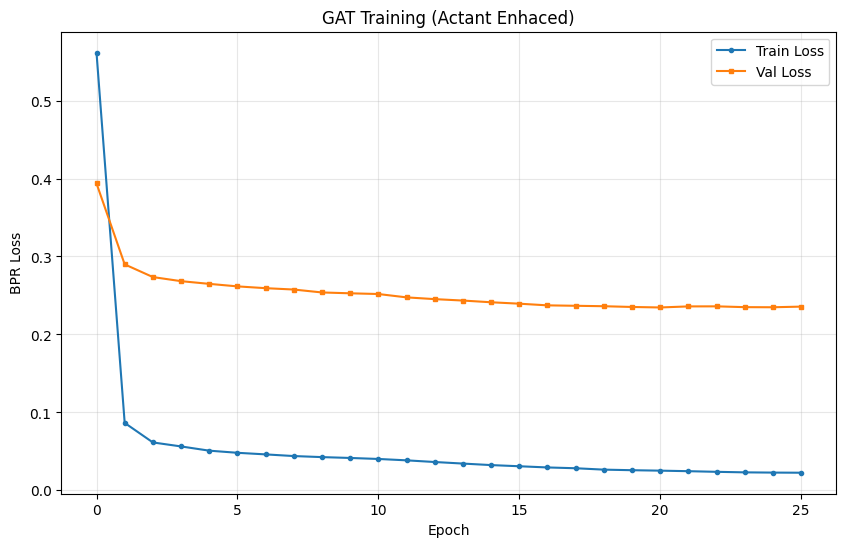

Final - Train: 0.0226, Val: 0.2357


In [46]:
# Simple device fix - just move your tensors to GPU
device = 'cuda' if torch.cuda.is_available() else 'cpu'

news_actant_tensor = news_actant_tensor.to(device)
news_category_indices = news_category_indices.to(device)

# ---- GAT Model ----
model_gat = UnifiedGNN(
    num_users=len(user_to_id),
    num_news=len(news_to_id),
    num_actants=len(actant_to_id),
    num_categories=len(cat_to_id),
    news_actant_tensor=news_actant_tensor,
    news_category_indices=news_category_indices,
    hidden_dim=32,
    actant_dim=16,
    cat_dim=8,
    num_layers=2,
    conv_type="GAT",
    dropout=0.3,
    heads=4,
    pad_idx=0
).to(device)

# Print model parameter counts
print(f"GAT: {sum(p.numel() for p in model_gat.parameters()):,} parameters")

train_losses, val_losses = train_model(
    model=model_gat,
    train_triplets=train_triplets,  # come from create_bpr_training_data
    val_triplets=val_triplets, # come from bpr loss
    edge_index=train_edge_index,
    epochs=30,           # Reduced epochs
    lr=0.0001,           # Learning rate
    weight_decay=1e-4,  # L2 regularization  
    patience=5          # Early stopping patience
)

plot_training_curves(train_losses, val_losses, "GAT Training (Actant Enhaced)")

SAGE: 5,431,888 parameters
Starting training for 30 epochs...
Train batches: 270, Val batches: 35
Epoch  1: Train Loss: 0.4397, Val Loss: 0.3754
         → New best validation loss!
Epoch  2: Train Loss: 0.0609, Val Loss: 0.3293
         → New best validation loss!
Epoch  3: Train Loss: 0.0403, Val Loss: 0.3222
         → New best validation loss!
Epoch  4: Train Loss: 0.0330, Val Loss: 0.3196
         → New best validation loss!
Epoch  5: Train Loss: 0.0284, Val Loss: 0.3178
         → New best validation loss!
Epoch  6: Train Loss: 0.0262, Val Loss: 0.3178
         → New best validation loss!
Epoch  7: Train Loss: 0.0241, Val Loss: 0.3168
         → New best validation loss!
Epoch  8: Train Loss: 0.0224, Val Loss: 0.3148
         → New best validation loss!
Epoch  9: Train Loss: 0.0213, Val Loss: 0.3150
         → No improvement (1/5)
Epoch 10: Train Loss: 0.0204, Val Loss: 0.3150
         → No improvement (2/5)
Epoch 11: Train Loss: 0.0195, Val Loss: 0.3132
         → New best valid

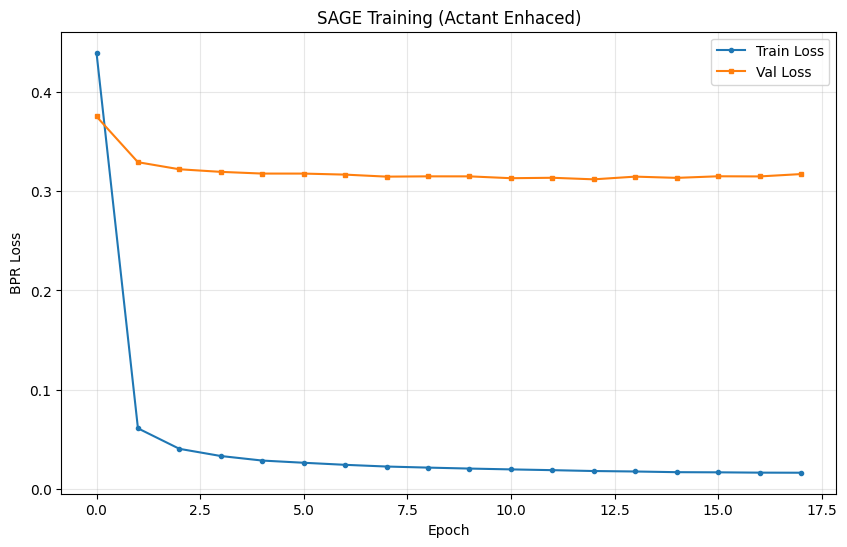

Final - Train: 0.0162, Val: 0.3173


In [47]:
model_sage = UnifiedGNN(
    num_users=len(user_to_id),
    num_news=len(news_to_id),
    num_actants=len(actant_to_id),
    num_categories=len(cat_to_id),
    news_actant_tensor=news_actant_tensor,
    news_category_indices=news_category_indices,
    hidden_dim=32,  # was 32 when loser
    actant_dim=16, # was 16
    cat_dim=8,
    num_layers=2, # was 2 for loswer
    conv_type="SAGE",
    dropout=0.3, # was 0.3 for being the loser
    pad_idx=0
).to(device)

print(f"SAGE: {sum(p.numel() for p in model_sage.parameters()):,} parameters")

train_losses, val_losses = train_model(
    model=model_sage,
    train_triplets=train_triplets,
    val_triplets=val_triplets, 
    edge_index=train_edge_index,
    epochs=30,           # Reduced epochs
    lr=0.0001,           # Learning rate
    weight_decay=1e-4,  # L2 regularization  
    patience=5          # Early stopping patience
)

plot_training_curves(train_losses, val_losses, "SAGE Training (Actant Enhaced)")

LightGCN: 5,427,728 parameters
Starting training for 30 epochs...
Train batches: 270, Val batches: 35
Epoch  1: Train Loss: 0.6850, Val Loss: 0.6915
         → New best validation loss!
Epoch  2: Train Loss: 0.6543, Val Loss: 0.6830
         → New best validation loss!
Epoch  3: Train Loss: 0.5020, Val Loss: 0.6491
         → New best validation loss!
Epoch  4: Train Loss: 0.2874, Val Loss: 0.6130
         → New best validation loss!
Epoch  5: Train Loss: 0.1737, Val Loss: 0.5898
         → New best validation loss!
Epoch  6: Train Loss: 0.1224, Val Loss: 0.5760
         → New best validation loss!
Epoch  7: Train Loss: 0.0963, Val Loss: 0.5669
         → New best validation loss!
Epoch  8: Train Loss: 0.0815, Val Loss: 0.5610
         → New best validation loss!
Epoch  9: Train Loss: 0.0725, Val Loss: 0.5569
         → New best validation loss!
Epoch 10: Train Loss: 0.0664, Val Loss: 0.5536
         → New best validation loss!
Epoch 11: Train Loss: 0.0622, Val Loss: 0.5516
         → 

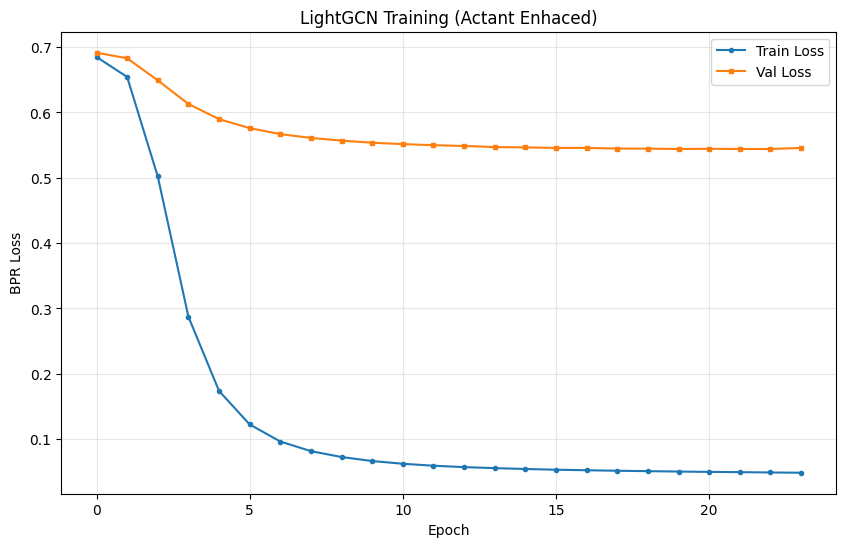

Final - Train: nan, Val: nan


In [48]:
model_lightgcn = UnifiedGNN(
    num_users=len(user_to_id),
    num_news=len(news_to_id),
    num_actants=len(actant_to_id),
    num_categories=len(cat_to_id),
    news_actant_tensor=news_actant_tensor,
    news_category_indices=news_category_indices,
    hidden_dim=32,
    actant_dim=16,
    cat_dim=8,
    num_layers=2,
    conv_type="LG",
    dropout=0.3,
    pad_idx=0
).to(device)

print(f"LightGCN: {sum(p.numel() for p in model_lightgcn.parameters()):,} parameters")

train_losses, val_losses = train_model(
    model=model_lightgcn,
    train_triplets=train_triplets,
    val_triplets=val_triplets, 
    edge_index=train_edge_index,
    epochs=30,           # Reduced epochs
    lr=0.0001,           # Learning rate
    weight_decay=1e-4,  # L2 regularization  
    patience=5          # Early stopping patience
)

plot_training_curves(train_losses, val_losses, "LightGCN Training (Actant Enhaced)")

In [49]:
import torch
import torch.nn.functional as F
import numpy as np
from collections import defaultdict
from sklearn.metrics import roc_auc_score

def evaluate_model_with_test_graph(
    model,
    train_edge_index,
    test_behaviors,
    test_data,        # dict: user_idx -> [clicked_news_indices]
    test_all_items,   # dict: user_idx -> [(news_idx, label), ...]
    train_triplets,
    user_to_id,
    news_to_id,
    k_values=[5, 10, 20],
    batch_size=100
):
    """
    Memory-safe, impression-based evaluation.
    Ranks each user's impression set, not the entire news corpus.
    """
    test_edge_index = build_test_graph_fixed(train_edge_index, test_behaviors, user_to_id, news_to_id)

    model.eval()
    with torch.no_grad():
        _, final_emb = model(test_edge_index)
        user_emb, news_emb = model.get_user_news_embeddings(final_emb)
        user_emb = F.normalize(user_emb, p=2, dim=1).cpu()
        news_emb = F.normalize(news_emb, p=2, dim=1).cpu()

    train_interactions = defaultdict(set)
    for user_idx, pos_item, _ in train_triplets:
        train_interactions[user_idx].add(pos_item)

    all_precisions = {k: [] for k in k_values}
    all_recalls = {k: [] for k in k_values}
    all_ndcgs = {k: [] for k in k_values}
    all_mrrs = []
    all_scores = []
    all_labels = []
    valid_users = 0

    def dcg_at_k(relevances, k):
        relevances = np.array(relevances)[:k]
        if len(relevances) == 0:
            return 0.0
        return np.sum(relevances / np.log2(np.arange(2, len(relevances) + 2)))
    def ndcg_at_k(relevances, k):
        dcg = dcg_at_k(relevances, k)
        ideal_relevances = sorted(relevances, reverse=True)
        idcg = dcg_at_k(ideal_relevances, k)
        return dcg / idcg if idcg > 0 else 0.0
    def reciprocal_rank(relevances):
        for i, rel in enumerate(relevances):
            if rel > 0:
                return 1.0 / (i + 1)
        return 0.0

    print(f"Evaluating {len(test_data)} test users in batches of {batch_size}...")

    user_indices = list(test_data.keys())
    for batch_start in range(0, len(user_indices), batch_size):
        batch_users = user_indices[batch_start: batch_start + batch_size]
        batch_user_emb = user_emb[batch_users]  # [batch_size, emb_dim]

        for i, user_idx in enumerate(batch_users):
            # Impression-based: use only this user's impression set
            if user_idx not in test_all_items:
                continue
            impression = test_all_items[user_idx]   # [(news_idx, label), ...]
            impression_news = [news_idx for news_idx, _ in impression]
            impression_labels = [label for _, label in impression]
            if len(impression_news) == 0:
                continue
            valid_users += 1

            user_vec = batch_user_emb[i]
            news_vecs = news_emb[impression_news]

            # Mask out train clicks
            for j, news_idx in enumerate(impression_news):
                if user_idx in train_interactions and news_idx in train_interactions[user_idx]:
                    impression_labels[j] = 0

            sims = torch.cosine_similarity(user_vec.unsqueeze(0), news_vecs).cpu().numpy()
            sorted_idx = np.argsort(-sims)
            ranked_labels = np.array(impression_labels)[sorted_idx]

            hits_k = lambda k: ranked_labels[:k].sum()
            n_rel = (np.array(impression_labels) == 1).sum()
            n_rel = max(1, n_rel)

            for k in k_values:
                all_precisions[k].append(hits_k(k) / k)
                all_recalls[k].append(hits_k(k) / n_rel)
                all_ndcgs[k].append(ndcg_at_k(ranked_labels, k))
            all_mrrs.append(reciprocal_rank(ranked_labels))

            all_scores.extend(list(sims))
            all_labels.extend(list(np.array(impression_labels)))

    results = {}
    results['valid_users'] = valid_users
    results['mrr'] = np.mean(all_mrrs) if all_mrrs else 0.0
    if len(set(all_labels)) > 1:
        try:
            results['auc'] = roc_auc_score(all_labels, all_scores)
        except Exception:
            results['auc'] = 0.0
    else:
        results['auc'] = 0.0
    for k in k_values:
        results[f'precision@{k}'] = np.mean(all_precisions[k]) if all_precisions[k] else 0.0
        results[f'recall@{k}'] = np.mean(all_recalls[k]) if all_recalls[k] else 0.0
        results[f'ndcg@{k}'] = np.mean(all_ndcgs[k]) if all_ndcgs[k] else 0.0

    print("--- Evaluation Complete ---")
    for k in k_values:
        print(f"P@{k}: {results[f'precision@{k}']:.5f}  "
              f"R@{k}: {results[f'recall@{k}']:.5f}  "
              f"nDCG@{k}: {results[f'ndcg@{k}']:.5f}")
    print(f"MRR: {results['mrr']:.5f}   AUC: {results['auc']:.5f}")

    print("LightGCN debug: Unique classes in all_labels:", set(all_labels))
    print("LightGCN debug: #Positives:", np.sum(np.array(all_labels)==1), " #Negatives:", np.sum(np.array(all_labels)==0))
    print("Sample of all_labels (first 30):", all_labels[:30])

    return results

In [50]:
results_gat = evaluate_model_with_test_graph(
    model=model_gat,  # or model_sage, model_lightgcn
    train_edge_index=train_edge_index,
    test_behaviors=test_behaviors, 
    test_data=test_data_proper,
    test_all_items=test_all_items,
    train_triplets=train_triplets,
    user_to_id=user_to_id,
    news_to_id=news_to_id,
    k_values=[5, 10, 20]
)

Building test graph with test interactions...
Test graph: 2327338 total edges (+1771868 from test)
Evaluating 19099 test users in batches of 100...
--- Evaluation Complete ---
P@5: 0.07578  R@5: 0.31187  nDCG@5: 0.21045
P@10: 0.06081  R@10: 0.48547  nDCG@10: 0.26922
P@20: 0.04539  R@20: 0.69194  nDCG@20: 0.32627
MRR: 0.23874   AUC: 0.54061
LightGCN debug: Unique classes in all_labels: {np.int64(0), np.int64(1)}
LightGCN debug: #Positives: 28705  #Negatives: 720358
Sample of all_labels (first 30): [np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]


In [51]:
results_sage = evaluate_model_with_test_graph(
    model=model_sage,  # or model_sage, model_lightgcn
    train_edge_index=train_edge_index,
    test_behaviors=test_behaviors, 
    test_data=test_data_proper,
    test_all_items=test_all_items,
    train_triplets=train_triplets,
    user_to_id=user_to_id,
    news_to_id=news_to_id,
    k_values=[5, 10, 20]
)

Building test graph with test interactions...
Test graph: 2327338 total edges (+1771868 from test)
Evaluating 19099 test users in batches of 100...
--- Evaluation Complete ---
P@5: 0.07166  R@5: 0.30578  nDCG@5: 0.19754
P@10: 0.05720  R@10: 0.46759  nDCG@10: 0.25226
P@20: 0.04237  R@20: 0.65939  nDCG@20: 0.30531
MRR: 0.21844   AUC: 0.40414
LightGCN debug: Unique classes in all_labels: {np.int64(0), np.int64(1)}
LightGCN debug: #Positives: 28705  #Negatives: 720358
Sample of all_labels (first 30): [np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]


In [52]:
results_lightgcn = evaluate_model_with_test_graph(
    model=model_lightgcn,  # or model_sage, model_lightgcn
    train_edge_index=train_edge_index,
    test_behaviors=test_behaviors, 
    test_data=test_data_proper,
    test_all_items=test_all_items,
    train_triplets=train_triplets,
    user_to_id=user_to_id,
    news_to_id=news_to_id,
    k_values=[5, 10, 20]
)

Building test graph with test interactions...
Test graph: 2327338 total edges (+1771868 from test)
Evaluating 19099 test users in batches of 100...
--- Evaluation Complete ---
P@5: 0.07711  R@5: 0.32552  nDCG@5: 0.21371
P@10: 0.06184  R@10: 0.50055  nDCG@10: 0.27367
P@20: 0.04511  R@20: 0.68992  nDCG@20: 0.32639
MRR: 0.23646   AUC: 0.00000
LightGCN debug: Unique classes in all_labels: {np.int64(0), np.int64(1)}
LightGCN debug: #Positives: 28705  #Negatives: 720358
Sample of all_labels (first 30): [np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]


In [53]:
print("### Results after content-based feature enahcement (Category+Actant_role) ####")
print_gnn_metrics(results_gat, model_name='GAT')
print()
print_gnn_metrics(results_sage, model_name='GraphSAGE')
print()
print_gnn_metrics(results_lightgcn, model_name='LightGCN')

### Results after content-based feature enahcement (Category+Actant_role) ####

GAT Model Evaluation Metrics
Users Evaluated: 19099

Metric                 @5          @10          @20
----------------------------------------------------
Precision         0.07578      0.06081      0.04539
Recall            0.31187      0.48547      0.69194
Ndcg              0.21045      0.26922      0.32627

MRR:  0.2387
AUC:  0.5406


GraphSAGE Model Evaluation Metrics
Users Evaluated: 19099

Metric                 @5          @10          @20
----------------------------------------------------
Precision         0.07166      0.05720      0.04237
Recall            0.30578      0.46759      0.65939
Ndcg              0.19754      0.25226      0.30531

MRR:  0.2184
AUC:  0.4041


LightGCN Model Evaluation Metrics
Users Evaluated: 19099

Metric                 @5          @10          @20
----------------------------------------------------
Precision         0.07711      0.06184      0.04511
Recall       

## 5.2: Add temporal features of news

In [54]:
def create_news_temporal_features(behaviors_df, news_to_id):
    """
    Create simple temporal features tensor for news (similar to actant tensor approach)
    """
    print("Creating news temporal features...")
    
    # Find first appearance time for each news
    news_first_time = {}
    
    for _, row in behaviors_df.iterrows():
        timestamp = row['timestamp']
        
        # Check impressions
        for news_id, _ in row['impressions']:
            if news_id in news_to_id and news_id not in news_first_time:
                news_first_time[news_id] = timestamp
        
        # Check history
        for news_id in row['history']:
            if news_id in news_to_id and news_id not in news_first_time:
                news_first_time[news_id] = timestamp
    
    # Create temporal tensor [num_news, 4]
    num_news = len(news_to_id)
    temporal_tensor = torch.zeros(num_news, 4)
    
    # Calculate reference times
    all_times = list(news_first_time.values())
    if all_times:
        min_time = min(all_times)
        max_time = max(all_times)
        time_range = (max_time - min_time).total_seconds()
    
    for news_id, news_idx in news_to_id.items():
        if news_id in news_first_time:
            first_time = news_first_time[news_id]
            
            # Feature 1: News age (0=newest, 1=oldest)
            age = (max_time - first_time).total_seconds() / time_range if time_range > 0 else 0
            
            # Feature 2: Hour of day (0-1)
            hour = first_time.hour / 23.0
            
            # Feature 3: Day of week (0-1)
            day = first_time.weekday() / 6.0
            
            # Feature 4: Freshness (1=newest, 0=oldest)
            freshness = 1.0 - age
            
            temporal_tensor[news_idx] = torch.tensor([age, hour, day, freshness])
    
    print(f"Temporal features created: {temporal_tensor.shape}")
    return temporal_tensor

# Create the temporal features tensor
news_temporal_features = create_news_temporal_features(behaviors_df, news_to_id)
news_temporal_features = news_temporal_features.to(device)  # Move to GPU

print(" News temporal features tensor ready!")

Creating news temporal features...
Temporal features created: torch.Size([65228, 4])
 News temporal features tensor ready!


In [55]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv, SAGEConv, LGConv
from torch.nn import ModuleList

class UnifiedGNN(nn.Module):
    """
    Unified GNN supporting SAGE, GAT, and LightGCN with actant, category, and temporal features.
    
    News node features:
    - Actant features: Pooled embeddings of semantic actants (mean of max_actants embeddings)
    - Category features: One-hot category embeddings
    - Temporal features: Direct 4D temporal signals (age, hour, day, freshness)
    """
    def __init__(
        self,
        num_users,
        num_news,
        num_actants,
        num_categories,             # total unique categories
        news_actant_tensor,         # [num_news, max_actants_per_news] torch.long
        news_category_indices,      # [num_news] torch.long, category idx for each news
        news_temporal_features,     # [num_news, 4] torch.float - NEW TEMPORAL FEATURES
        hidden_dim=32,
        actant_dim=16,
        cat_dim=8,                 # category embedding dimension
        temporal_dim=4,            # temporal feature dimension (fixed at 4)
        num_layers=2,
        conv_type="GAT",
        dropout=0.2,
        heads=4,
        pad_idx=0,
    ):
        super().__init__()
        self.num_users = num_users
        self.num_news = num_news
        self.num_actants = num_actants
        self.num_categories = num_categories
        self.hidden_dim = hidden_dim
        self.actant_dim = actant_dim
        self.cat_dim = cat_dim
        self.temporal_dim = temporal_dim  # NEW: temporal dimension
        self.num_layers = num_layers
        self.conv_type = conv_type
        self.dropout = dropout
        self.pad_idx = pad_idx

        # === Embedding layers for all node IDs ===
        total_nodes = num_users + num_news
        self.embedding = nn.Embedding(total_nodes, hidden_dim)         # User/news base embedding

        # === Actant embedding for pooled news actants ===
        self.actant_embedding = nn.Embedding(num_actants, actant_dim, padding_idx=pad_idx)

        # === Category embedding for news categories ===
        self.category_embedding = nn.Embedding(num_categories, cat_dim, padding_idx=0)

        # === Register precomputed features as buffers for device safety ===
        self.register_buffer('news_actant_tensor', news_actant_tensor)       # [num_news, max_actants]
        self.register_buffer('news_category_indices', news_category_indices) # [num_news]
        self.register_buffer('news_temporal_features', news_temporal_features) # [num_news, 4] - NEW

        # === Project concatenated features to hidden_dim ===
        # Input: hidden_dim + actant_dim + cat_dim + temporal_dim
        # Output: hidden_dim
        input_dim = hidden_dim + actant_dim + cat_dim + temporal_dim
        self.proj_news = nn.Linear(input_dim, hidden_dim)

        # === GNN Layers ===
        if conv_type == "SAGE":
            self.convs = ModuleList([
                SAGEConv(hidden_dim, hidden_dim)
                for _ in range(num_layers)
            ])
        elif conv_type == "GAT":
            self.convs = ModuleList([
                GATConv(hidden_dim, hidden_dim, heads=heads, concat=False,
                        dropout=dropout, add_self_loops=False)
                for _ in range(num_layers)
            ])
        elif conv_type == "LG":
            self.convs = ModuleList([
                LGConv() for _ in range(num_layers)
            ])

        # === Initialize embeddings ===
        nn.init.normal_(self.embedding.weight, std=0.1)
        nn.init.normal_(self.actant_embedding.weight, std=0.1)
        nn.init.normal_(self.category_embedding.weight, std=0.1)
        self.dropout_layer = nn.Dropout(dropout)

    def forward(self, edge_index):
        """
        Forward pass for bipartite graph with actant, category, and temporal features.
        
        Feature flow:
        1. Base embeddings: [num_users + num_news, hidden_dim]
        2. News enhancement:
           - Actant: [num_news, actant_dim] (pooled from actant embeddings)
           - Category: [num_news, cat_dim] (embedded category indices)
           - Temporal: [num_news, temporal_dim] (direct temporal features)
        3. Concatenation: [num_news, hidden_dim + actant_dim + cat_dim + temporal_dim]
        4. Projection: [num_news, hidden_dim]
        5. GNN propagation: All nodes [num_users + num_news, hidden_dim]
        """
        # Base node embeddings (users + news)
        x = self.embedding.weight  # [total_nodes, hidden_dim]

        # Actant features (pooled embeddings)
        actant_embeds = self.actant_embedding(self.news_actant_tensor)     # [num_news, max_actants, actant_dim]
        pooled_actant_embeds = actant_embeds.mean(dim=1)                  # [num_news, actant_dim]

        # Category features (embedded indices)
        cat_embeds = self.category_embedding(self.news_category_indices)   # [num_news, cat_dim]

        # === Step 4: Temporal features (direct features)
        temporal_embeds = self.news_temporal_features                      # [num_news, temporal_dim] - NEW

        # Concatenate all news features
        news_emb = x[self.num_users:]                                     # [num_news, hidden_dim]
        news_aug = torch.cat([
            news_emb,                # Base news embeddings
            pooled_actant_embeds,    # Actant features  
            cat_embeds,              # Category features
            temporal_embeds          # Temporal features - NEW
        ], dim=1)  # [num_news, hidden_dim + actant_dim + cat_dim + temporal_dim]
        
        # Project to hidden dimension ===
        news_aug = self.proj_news(news_aug)                               # [num_news, hidden_dim]
        
        # User nodes unchanged
        user_emb = x[:self.num_users]                                     # [num_users, hidden_dim]

        # Combine all nodes
        x = torch.cat([user_emb, news_aug], dim=0)                        # [total_nodes, hidden_dim]

        # GNN Propagation
        if self.conv_type == "LG":
            # LightGCN: Average all layer outputs
            layer_embs = [x]
            for conv in self.convs:
                x = conv(x, edge_index)
                layer_embs.append(x)
            final_emb = torch.mean(torch.stack(layer_embs), dim=0)
        else:
            # GAT/SAGE: Sequential layers with activation
            for i, conv in enumerate(self.convs):
                x = conv(x, edge_index)
                if i < len(self.convs) - 1:  # No activation on final layer
                    x = F.relu(x)
                    x = self.dropout_layer(x)
            final_emb = x

        return self.embedding.weight, final_emb

    def get_user_news_embeddings(self, final_emb):
        """
        Split final embeddings into user and news parts.
        
        Args:
            final_emb: [num_users + num_news, hidden_dim]
            
        Returns:
            user_emb: [num_users, hidden_dim]
            news_emb: [num_news, hidden_dim]
        """
        user_emb = final_emb[:self.num_users]
        news_emb = final_emb[self.num_users:]
        return user_emb, news_emb

=== TRAINING GAT WITH TEMPORAL FEATURES ===
LightGCN: 10,892,560 parameters
Starting training for 30 epochs...
Train batches: 270, Val batches: 35
Epoch  1: Train Loss: 0.3972, Val Loss: 0.2902
         → New best validation loss!
Epoch  2: Train Loss: 0.0671, Val Loss: 0.2601
         → New best validation loss!
Epoch  3: Train Loss: 0.0537, Val Loss: 0.2567
         → New best validation loss!
Epoch  4: Train Loss: 0.0491, Val Loss: 0.2568
         → No improvement (1/5)
Epoch  5: Train Loss: 0.0466, Val Loss: 0.2551
         → New best validation loss!
Epoch  6: Train Loss: 0.0443, Val Loss: 0.2513
         → New best validation loss!
Epoch  7: Train Loss: 0.0408, Val Loss: 0.2483
         → New best validation loss!
Epoch  8: Train Loss: 0.0379, Val Loss: 0.2459
         → New best validation loss!
Epoch  9: Train Loss: 0.0353, Val Loss: 0.2453
         → New best validation loss!
Epoch 10: Train Loss: 0.0332, Val Loss: 0.2450
         → New best validation loss!
Epoch 11: Train Lo

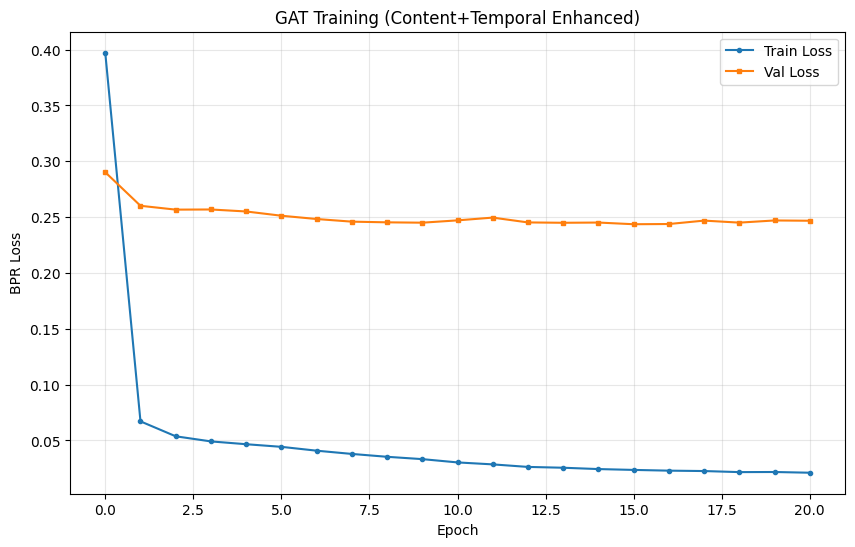

Final - Train: 0.0211, Val: 0.2468


In [56]:
print("=== TRAINING GAT WITH TEMPORAL FEATURES ===")

model_gat = UnifiedGNN(
    num_users=len(user_to_id),
    num_news=len(news_to_id),
    num_actants=len(actant_to_id),
    num_categories=len(cat_to_id),
    news_actant_tensor=news_actant_tensor,
    news_category_indices=news_category_indices,
    news_temporal_features=news_temporal_features,  # NEW temporal features
    hidden_dim=64,
    actant_dim=32,
    cat_dim=8,
    temporal_dim=4,  # NEW temporal dimension
    num_layers=2,
    conv_type="GAT",
    dropout=0.3,
    heads=4,
    pad_idx=0
).to(device)

print(f"LightGCN: {sum(p.numel() for p in model_gat.parameters()):,} parameters")

train_losses_gat, val_losses_gat = train_model(
    model=model_gat,
    train_triplets=train_triplets,
    val_triplets=val_triplets, 
    edge_index=train_edge_index,
    epochs=30,
    lr=0.0001,
    weight_decay=1e-4,
    patience=5
)

plot_training_curves(train_losses_gat, val_losses_gat, "GAT Training (Content+Temporal Enhanced)")

=== TRAINING SAGE WITH TEMPORAL FEATURES ===
LightGCN: 10,875,152 parameters
Starting training for 30 epochs...
Train batches: 270, Val batches: 35
Epoch  1: Train Loss: 0.2127, Val Loss: 0.3624
         → New best validation loss!
Epoch  2: Train Loss: 0.0487, Val Loss: 0.3619
         → New best validation loss!
Epoch  3: Train Loss: 0.0342, Val Loss: 0.3627
         → No improvement (1/5)
Epoch  4: Train Loss: 0.0282, Val Loss: 0.3656
         → No improvement (2/5)
Epoch  5: Train Loss: 0.0244, Val Loss: 0.3634
         → No improvement (3/5)
Epoch  6: Train Loss: 0.0219, Val Loss: 0.3602
         → New best validation loss!
Epoch  7: Train Loss: 0.0204, Val Loss: 0.3583
         → New best validation loss!
Epoch  8: Train Loss: 0.0187, Val Loss: 0.3653
         → No improvement (1/5)
Epoch  9: Train Loss: 0.0178, Val Loss: 0.3547
         → New best validation loss!
Epoch 10: Train Loss: 0.0171, Val Loss: 0.3572
         → No improvement (1/5)
Epoch 11: Train Loss: 0.0164, Val Los

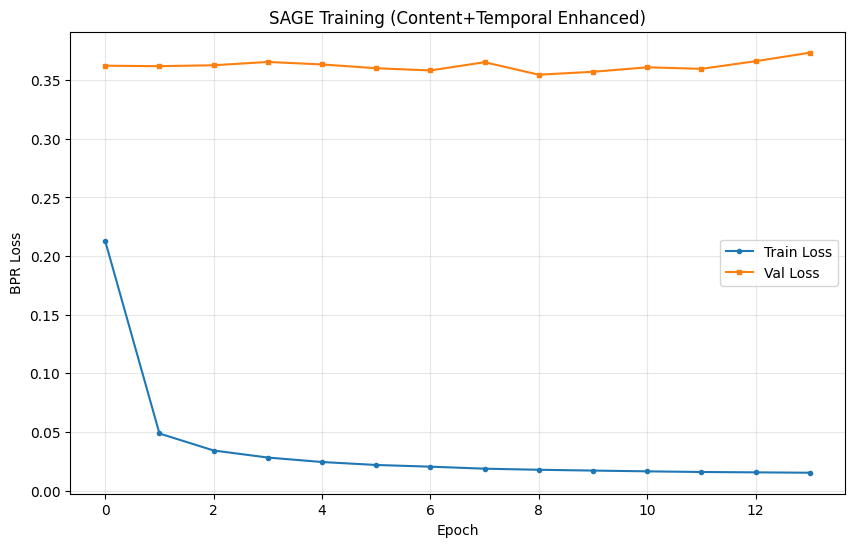

Final - Train: 0.0153, Val: 0.3734


In [57]:
print("=== TRAINING SAGE WITH TEMPORAL FEATURES ===")

model_sage = UnifiedGNN(
    num_users=len(user_to_id),
    num_news=len(news_to_id),
    num_actants=len(actant_to_id),
    num_categories=len(cat_to_id),
    news_actant_tensor=news_actant_tensor,
    news_category_indices=news_category_indices,
    news_temporal_features=news_temporal_features,  # NEW temporal features
    hidden_dim=64,
    actant_dim=32,
    cat_dim=8,
    temporal_dim=4,  # NEW temporal dimension
    num_layers=2,
    conv_type="SAGE",
    dropout=0.3,
    pad_idx=0
).to(device)

print(f"LightGCN: {sum(p.numel() for p in model_sage.parameters()):,} parameters")

train_losses_sage, val_losses_sage = train_model(
    model=model_sage,
    train_triplets=train_triplets,
    val_triplets=val_triplets, 
    edge_index=train_edge_index,
    epochs=30,
    lr=0.0001,
    weight_decay=1e-4,
    patience=5
)
plot_training_curves(train_losses_sage, val_losses_sage, "SAGE Training (Content+Temporal Enhanced)")

=== TRAINING LIGHTGCN WITH TEMPORAL FEATURES ===
LightGCN: 10,858,640 parameters
Starting training for 30 epochs...
Train batches: 270, Val batches: 35
Epoch  1: Train Loss: 0.6442, Val Loss: 0.6754
         → New best validation loss!
Epoch  2: Train Loss: 0.3928, Val Loss: 0.6141
         → New best validation loss!
Epoch  3: Train Loss: 0.1631, Val Loss: 0.5762
         → New best validation loss!
Epoch  4: Train Loss: 0.0946, Val Loss: 0.5594
         → New best validation loss!
Epoch  5: Train Loss: 0.0713, Val Loss: 0.5513
         → New best validation loss!
Epoch  6: Train Loss: 0.0609, Val Loss: 0.5465
         → New best validation loss!
Epoch  7: Train Loss: 0.0555, Val Loss: 0.5431
         → New best validation loss!
Epoch  8: Train Loss: 0.0521, Val Loss: 0.5412
         → New best validation loss!
Epoch  9: Train Loss: 0.0498, Val Loss: 0.5403
         → New best validation loss!
Epoch 10: Train Loss: 0.0482, Val Loss: 0.5392
         → New best validation loss!
Epoch 11

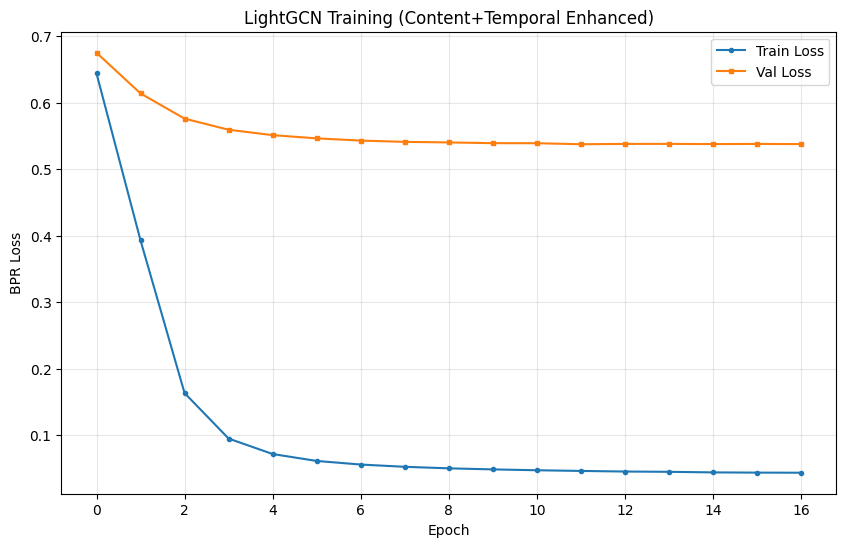

Final - Train: 0.0432, Val: 0.5378


In [58]:
print("=== TRAINING LIGHTGCN WITH TEMPORAL FEATURES ===")

model_lightgcn = UnifiedGNN(
    num_users=len(user_to_id),
    num_news=len(news_to_id),
    num_actants=len(actant_to_id),
    num_categories=len(cat_to_id),
    news_actant_tensor=news_actant_tensor,
    news_category_indices=news_category_indices,
    news_temporal_features=news_temporal_features,  # NEW temporal features
    hidden_dim=64,
    actant_dim=32,
    cat_dim=8,
    temporal_dim=4,  # NEW temporal dimension
    num_layers=3,    # More layers for LightGCN
    conv_type="LG",
    dropout=0.2,     # Lower dropout for LightGCN
    pad_idx=0
).to(device)

print(f"LightGCN: {sum(p.numel() for p in model_lightgcn.parameters()):,} parameters")

train_losses_lightgcn, val_losses_lightgcn = train_model(
    model=model_lightgcn,
    train_triplets=train_triplets,
    val_triplets=val_triplets, 
    edge_index=train_edge_index,
    epochs=30,
    lr=0.0001,
    weight_decay=1e-4,
    patience=5
)

plot_training_curves(train_losses_lightgcn, val_losses_lightgcn, "LightGCN Training (Content+Temporal Enhanced)")

In [59]:
print("=== EVALUATING TEMPORAL ENHANCED MODELS ===")


results_gat_temporal = evaluate_model_with_test_graph(
    model=model_gat,
    train_edge_index=train_edge_index,
    test_behaviors=test_behaviors, 
    test_data=test_data_proper,
    test_all_items=test_all_items,
    train_triplets=train_triplets,
    user_to_id=user_to_id,
    news_to_id=news_to_id,
    k_values=[5, 10, 20]
)


results_sage_temporal = evaluate_model_with_test_graph(
    model=model_sage,
    train_edge_index=train_edge_index,
    test_behaviors=test_behaviors, 
    test_data=test_data_proper,
    test_all_items=test_all_items,
    train_triplets=train_triplets,
    user_to_id=user_to_id,
    news_to_id=news_to_id,
    k_values=[5, 10, 20]
)


results_lightgcn_temporal = evaluate_model_with_test_graph(
    model=model_lightgcn,
    train_edge_index=train_edge_index,
    test_behaviors=test_behaviors, 
    test_data=test_data_proper,
    test_all_items=test_all_items,
    train_triplets=train_triplets,
    user_to_id=user_to_id,
    news_to_id=news_to_id,
    k_values=[5, 10, 20]
)

=== EVALUATING TEMPORAL ENHANCED MODELS ===
Building test graph with test interactions...
Test graph: 2327338 total edges (+1771868 from test)
Evaluating 19099 test users in batches of 100...
--- Evaluation Complete ---
P@5: 0.07157  R@5: 0.30372  nDCG@5: 0.20711
P@10: 0.05785  R@10: 0.47202  nDCG@10: 0.26445
P@20: 0.04262  R@20: 0.65792  nDCG@20: 0.31582
MRR: 0.23258   AUC: 0.44178
LightGCN debug: Unique classes in all_labels: {np.int64(0), np.int64(1)}
LightGCN debug: #Positives: 28705  #Negatives: 720358
Sample of all_labels (first 30): [np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]
Building test graph with test interactions...
Test graph: 23273

In [60]:
print_gnn_metrics(results_gat_temporal, model_name='GAT (Content+Temporal)')
print()
print_gnn_metrics(results_sage_temporal, model_name='GraphSAGE (Content+Temporal)')
print()
print_gnn_metrics(results_lightgcn_temporal, model_name='LightGCN (Content+Temporal)')


GAT (Content+Temporal) Model Evaluation Metrics
Users Evaluated: 19099

Metric                 @5          @10          @20
----------------------------------------------------
Precision         0.07157      0.05785      0.04262
Recall            0.30372      0.47202      0.65792
Ndcg              0.20711      0.26445      0.31582

MRR:  0.2326
AUC:  0.4418


GraphSAGE (Content+Temporal) Model Evaluation Metrics
Users Evaluated: 19099

Metric                 @5          @10          @20
----------------------------------------------------
Precision         0.07502      0.05959      0.04332
Recall            0.32295      0.48814      0.66972
Ndcg              0.20823      0.26483      0.31537

MRR:  0.2263
AUC:  0.4320


LightGCN (Content+Temporal) Model Evaluation Metrics
Users Evaluated: 19099

Metric                 @5          @10          @20
----------------------------------------------------
Precision         0.07619      0.06117      0.04520
Recall            0.31518      0.48

# 6: Other Baselines

## 6.1: Random Recomendation

In [61]:
def random_baseline_comprehensive(test_data, train_triplets, total_news, k_values=[5, 10, 20]):
    """
    Comprehensive random recommendation baseline with all metrics
    (nDCG@K, Recall@K, Precision@K, MRR, AUC)
    """
    
    def dcg_at_k(relevances, k):
        """Compute Discounted Cumulative Gain at k"""
        relevances = np.array(relevances)[:k]
        if len(relevances) == 0:
            return 0.0
        return np.sum(relevances / np.log2(np.arange(2, len(relevances) + 2)))
    
    def ndcg_at_k(relevances, k):
        """Compute Normalized Discounted Cumulative Gain at k"""
        dcg = dcg_at_k(relevances, k)
        ideal_relevances = sorted(relevances, reverse=True)
        idcg = dcg_at_k(ideal_relevances, k)
        return dcg / idcg if idcg > 0 else 0.0
    
    def reciprocal_rank(relevances):
        """Compute reciprocal rank"""
        for i, rel in enumerate(relevances):
            if rel > 0:
                return 1.0 / (i + 1)
        return 0.0
    
    # Get warm users (users with training data)
    train_users = set(user_idx for user_idx, _, _ in train_triplets)
    
    print(f"Random baseline evaluating {len(test_data)} TEST users...")
    
    # Initialize metric collectors
    all_precisions = {k: [] for k in k_values}
    all_recalls = {k: [] for k in k_values}
    all_ndcgs = {k: [] for k in k_values}
    all_mrrs = []
    
    # For AUC calculation
    all_scores = []
    all_labels = []
    
    valid_users = 0
    
    for user_idx, test_items in test_data.items():
        if len(test_items) == 0:
            continue
            
        valid_users += 1
        test_items_set = set(test_items)
        
        # Generate random ranking for all news items
        all_items = list(range(total_news))
        random.shuffle(all_items)
        
        # Create random scores (simulate random similarity scores)
        random_scores = np.random.random(total_news)
        
        # Create relevance vector
        relevances = [1 if item in test_items_set else 0 for item in all_items]
        
        # For AUC: sample some items and their scores/labels
        sample_size = min(1000, total_news)
        sample_indices = random.sample(range(total_news), sample_size)
        
        for idx in sample_indices:
            all_scores.append(random_scores[idx])
            all_labels.append(1 if idx in test_items_set else 0)
        
        # Calculate MRR
        mrr = reciprocal_rank(relevances)
        all_mrrs.append(mrr)
        
        # Calculate metrics for each k
        for k in k_values:
            # Get top-k random items
            top_k_items = set(all_items[:k])
            
            # Precision@K
            hits = len(top_k_items & test_items_set)
            precision = hits / k
            all_precisions[k].append(precision)
            
            # Recall@K
            recall = hits / len(test_items_set)
            all_recalls[k].append(recall)
            
            # nDCG@K
            ndcg = ndcg_at_k(relevances, k)
            all_ndcgs[k].append(ndcg)
    
    # Compute final results
    results = {}
    results['valid_users'] = valid_users
    results['mrr'] = np.mean(all_mrrs) if all_mrrs else 0.0
    
    # Compute AUC (should be around 0.5 for random)
    if len(all_scores) > 0 and len(set(all_labels)) > 1:
        results['auc'] = roc_auc_score(all_labels, all_scores)
    else:
        results['auc'] = 0.5  # Expected value for random
    
    # Compute metrics for each k
    for k in k_values:
        results[f'precision@{k}'] = np.mean(all_precisions[k]) if all_precisions[k] else 0.0
        results[f'recall@{k}'] = np.mean(all_recalls[k]) if all_recalls[k] else 0.0
        results[f'ndcg@{k}'] = np.mean(all_ndcgs[k]) if all_ndcgs[k] else 0.0
    
    return results

def compare_results(model_results, random_results, k_values=[5, 10, 20]):
    """Compare model results with random baseline"""
    
    print("=" * 80)
    print("  MODEL vs RANDOM BASELINE COMPARISON")
    print("=" * 80)
    
    print(f"{'Metric':<15} {'Model':<12} {'Random':<12} {'Improvement':<12}")
    print("-" * 60)
    
    # Compare ranking metrics
    for k in k_values:
        for metric in ['precision', 'recall', 'ndcg']:
            model_val = model_results[f'{metric}@{k}']
            random_val = random_results[f'{metric}@{k}']
            improvement = f"{model_val/random_val:.1f}x" if random_val > 0 else "∞"
            
            print(f"{metric}@{k:<9} {model_val:<12.4f} {random_val:<12.4f} {improvement:<12}")
    
    print("-" * 60)
    
    # Compare overall metrics
    for metric in ['mrr', 'auc']:
        model_val = model_results[metric]
        random_val = random_results[metric]
        improvement = f"{model_val/random_val:.1f}x" if random_val > 0 else "∞"
        
        print(f"{metric.upper():<15} {model_val:<12.4f} {random_val:<12.4f} {improvement:<12}")
    
    print("\n  INTERPRETATION:")
    print("-" * 40)
    
    # Check if model is better than random
    better_metrics = 0
    total_metrics = 0
    
    for k in k_values:
        for metric in ['precision', 'recall', 'ndcg']:
            total_metrics += 1
            if model_results[f'{metric}@{k}'] > random_results[f'{metric}@{k}']:
                better_metrics += 1
    
    if model_results['mrr'] > random_results['mrr']:
        better_metrics += 1
    if model_results['auc'] > random_results['auc']:
        better_metrics += 1
    total_metrics += 2
    
    performance_ratio = better_metrics / total_metrics
    
    if performance_ratio >= 0.8:
        print(f"  Model significantly outperforms random ({better_metrics}/{total_metrics} metrics)")
    elif performance_ratio >= 0.5:
        print(f"   Model moderately outperforms random ({better_metrics}/{total_metrics} metrics)")
    else:
        print(f" Model barely outperforms random ({better_metrics}/{total_metrics} metrics)")

# Run comprehensive random baseline
print("=== COMPREHENSIVE RANDOM BASELINE ===")
random_results = random_baseline_comprehensive(test_data, train_triplets, len(news_to_id))

print("=== RANDOM BASELINE RESULTS ===")
for key, val in random_results.items():
    print(f"{key:>12}: {val:.4f}" if isinstance(val, float) else f"{key:>12}: {val}")

=== COMPREHENSIVE RANDOM BASELINE ===
Random baseline evaluating 19099 TEST users...
=== RANDOM BASELINE RESULTS ===
 valid_users: 19099
         mrr: 0.0003
         auc: 0.5004
 precision@5: 0.0000
    recall@5: 0.0001
      ndcg@5: 0.0001
precision@10: 0.0000
   recall@10: 0.0002
     ndcg@10: 0.0001
precision@20: 0.0000
   recall@20: 0.0003
     ndcg@20: 0.0001


## 6.2 Popularity-Based Recommendation

Implementing a popularity-based recommendation of the news. This will mean calculating the top k nodes in terms of their degrees. Then we will evaluate them on the test set. Popularity baselines are often strong in news recommendation because some news genuinely appeals to many users!

In [62]:
# New cell: Popularity-based recommendation system
def create_popularity_baseline(train_triplets, total_news, k_values=[5, 10, 20]):
    """
    Create popularity-based recommendations using news degrees (click counts)
    """
    # Count clicks for each news item (degree = popularity)
    news_popularity = defaultdict(int)
    
    for user_idx, pos_item, _ in train_triplets:
        news_popularity[pos_item] += 1
    
    # Sort news by popularity (descending)
    sorted_news = sorted(news_popularity.items(), key=lambda x: x[1], reverse=True)
    
    print(f"=== POPULARITY ANALYSIS ===")
    print(f"Total news items in training: {len(news_popularity)}")
    print(f"Most popular news items:")
    for i, (news_id, count) in enumerate(sorted_news[:10]):
        print(f"  {i+1:2d}. News {news_id}: {count:,} clicks")
    
    # Create top-K popular items for each K
    popular_items = {}
    for k in k_values:
        popular_items[k] = [news_id for news_id, _ in sorted_news[:k]]
        print(f"Top-{k} popular items: {len(popular_items[k])} items")
    
    return popular_items, news_popularity

def evaluate_popularity_baseline(test_data, popular_items, news_popularity, k_values=[5, 10, 20]):
    """
    Evaluate popularity baseline with comprehensive metrics
    """
    
    def dcg_at_k(relevances, k):
        relevances = np.array(relevances)[:k]
        if len(relevances) == 0:
            return 0.0
        return np.sum(relevances / np.log2(np.arange(2, len(relevances) + 2)))
    
    def ndcg_at_k(relevances, k):
        dcg = dcg_at_k(relevances, k)
        ideal_relevances = sorted(relevances, reverse=True)
        idcg = dcg_at_k(ideal_relevances, k)
        return dcg / idcg if idcg > 0 else 0.0
    
    def reciprocal_rank(relevances):
        for i, rel in enumerate(relevances):
            if rel > 0:
                return 1.0 / (i + 1)
        return 0.0
    
    print(f"Popularity baseline evaluating {len(test_data)} test users...")
    
    # Initialize metric collectors
    all_precisions = {k: [] for k in k_values}
    all_recalls = {k: [] for k in k_values}
    all_ndcgs = {k: [] for k in k_values}
    all_mrrs = []
    
    # For AUC calculation
    all_scores = []
    all_labels = []
    
    # Sort all news by popularity for ranking
    sorted_news_by_popularity = sorted(news_popularity.items(), key=lambda x: x[1], reverse=True)
    popularity_ranking = [news_id for news_id, _ in sorted_news_by_popularity]
    popularity_scores = {news_id: score for news_id, score in sorted_news_by_popularity}
    
    valid_users = 0
    
    for user_idx, test_items in test_data.items():
        if len(test_items) == 0:
            continue
            
        valid_users += 1
        test_items_set = set(test_items)
        
        # Create relevance vector based on popularity ranking
        relevances = [1 if item in test_items_set else 0 for item in popularity_ranking]
        
        # For AUC: sample some items and their popularity scores
        sample_size = min(1000, len(popularity_ranking))
        sample_items = random.sample(popularity_ranking, sample_size)
        
        for item in sample_items:
            # Use popularity score (higher = more likely to be recommended)
            score = popularity_scores.get(item, 0)
            all_scores.append(score)
            all_labels.append(1 if item in test_items_set else 0)
        
        # Calculate MRR based on popularity ranking
        mrr = reciprocal_rank(relevances)
        all_mrrs.append(mrr)
        
        # Calculate metrics for each k
        for k in k_values:
            # Get top-k popular items
            top_k_popular = set(popular_items[k])
            
            # Precision@K
            hits = len(top_k_popular & test_items_set)
            precision = hits / k
            all_precisions[k].append(precision)
            
            # Recall@K
            recall = hits / len(test_items_set)
            all_recalls[k].append(recall)
            
            # nDCG@K (based on popularity ranking)
            ndcg = ndcg_at_k(relevances, k)
            all_ndcgs[k].append(ndcg)
    
    # Compute final results
    results = {}
    results['valid_users'] = valid_users
    results['mrr'] = np.mean(all_mrrs) if all_mrrs else 0.0
    
    # Compute AUC
    if len(all_scores) > 0 and len(set(all_labels)) > 1:
        results['auc'] = roc_auc_score(all_labels, all_scores)
    else:
        results['auc'] = 0.0
    
    # Compute metrics for each k
    for k in k_values:
        results['precision@{}'.format(k)] = np.mean(all_precisions[k]) if all_precisions[k] else 0.0
        results['recall@{}'.format(k)] = np.mean(all_recalls[k]) if all_recalls[k] else 0.0
        results['ndcg@{}'.format(k)] = np.mean(all_ndcgs[k]) if all_ndcgs[k] else 0.0
    
    return results

# Create popularity baseline
print("=== CREATING POPULARITY BASELINE ===")
popular_items, news_popularity = create_popularity_baseline(train_triplets, len(news_to_id))

# Evaluate popularity baseline
print("\n=== EVALUATING POPULARITY BASELINE ===")
popularity_results = evaluate_popularity_baseline(test_data, popular_items, news_popularity)

# Print results
print("=== POPULARITY BASELINE RESULTS ===")
for key, val in popularity_results.items():
    print(f"{key:>12}: {val:.4f}" if isinstance(val, float) else f"{key:>12}: {val}")

=== CREATING POPULARITY BASELINE ===
=== POPULARITY ANALYSIS ===
Total news items in training: 8367
Most popular news items:
   1. News 50759: 4,257 clicks
   2. News 29749: 3,690 clicks
   3. News 24395: 3,671 clicks
   4. News 28583: 3,281 clicks
   5. News 26241: 3,214 clicks
   6. News 11153: 2,916 clicks
   7. News 48422: 2,824 clicks
   8. News 54881: 2,676 clicks
   9. News 59958: 2,550 clicks
  10. News 15015: 2,544 clicks
Top-5 popular items: 5 items
Top-10 popular items: 10 items
Top-20 popular items: 20 items

=== EVALUATING POPULARITY BASELINE ===
Popularity baseline evaluating 19099 test users...
=== POPULARITY BASELINE RESULTS ===
 valid_users: 19099
         mrr: 0.0258
         auc: 0.6834
 precision@5: 0.0131
    recall@5: 0.0400
      ndcg@5: 0.0251
precision@10: 0.0085
   recall@10: 0.0504
     ndcg@10: 0.0293
precision@20: 0.0045
   recall@20: 0.0532
     ndcg@20: 0.0303


# 7: Compliing All baseline results

## Model Performance Comparison: Classical vs. Graph-based Approaches

| Model          | Prec\@5 | Rec\@5 | nDCG\@5 | Prec\@10 | Rec\@10 | nDCG\@10 | Prec\@20 | Rec\@20 | nDCG\@20 | MRR    | AUC    |
| -------------- | ------- | ------ | ------- | -------- | ------- | -------- | -------- | ------- | -------- | ------ | ------ |
| **Popularity** | 0.0131  | 0.0400 | 0.0251  | 0.0085   | 0.0504  | 0.0293   | 0.0045   | 0.0532  | 0.0303   | 0.0258 | 0.6859 |
| **Random**     | 0.0000  | 0.0000 | 0.0000  | 0.0000   | 0.0001  | 0.0000   | 0.0000   | 0.0002  | 0.0001   | 0.0002 | 0.4882 |

### Graph-based Approaches (No Node Features)

| Model        | Prec\@5 | Rec\@5  | nDCG\@5 | Prec\@10 | Rec\@10 | nDCG\@10 | Prec\@20 | Rec\@20 | nDCG\@20 | MRR    | AUC    |
| ------------ | ------- | ------- | ------- | -------- | ------- | -------- | -------- | ------- | -------- | ------ | ------ |
| **GAT**      | 0.07086 | 0.30099 | 0.20553 | 0.05704  | 0.46598 | 0.26168  | 0.04293  | 0.66796 | 0.31700  | 0.2321 | 0.4462 |
| **SAGE**     | 0.07189 | 0.30452 | 0.20022 | 0.05809  | 0.47016 | 0.25671  | 0.04405  | 0.67745 | 0.31366  | 0.2242 | 0.4969 |
| **LightGCN** | 0.07640 | 0.32005 | 0.21818 | 0.06164  | 0.49540 | 0.27807  | 0.04596  | 0.69635 | 0.33409  | 0.2447 | 0.5451 |

### With News Node Features (category + entity_role)

| Model        | Prec\@5 | Rec\@5  | nDCG\@5 | Prec\@10 | Rec\@10 | nDCG\@10 | Prec\@20 | Rec\@20 | nDCG\@20 | MRR    | AUC    |
| ------------ | ------- | ------- | ------- | -------- | ------- | -------- | -------- | ------- | -------- | ------ | ------ |
| **GAT**      | 0.08201 | 0.33247 | 0.22956 | 0.06336  | 0.49713 | 0.28576  | 0.04704  | 0.70454 | 0.34320  | 0.2626 | 0.5750 |
| **SAGE**     | 0.07577 | 0.32445 | 0.20845 | 0.05911  | 0.48459 | 0.26293  | 0.04302  | 0.66654 | 0.31358  | 0.2268 | 0.4289 |
| **LightGCN** | 0.07711 | 0.32552 | 0.21371 | 0.06184  | 0.50055 | 0.27367  | 0.04511  | 0.68992 | 0.32639  | 0.2365 | 0.4700 |

### With News Node Features (category + entity_role + temporal features)

| Model              | Prec\@5 | Rec\@5  | nDCG\@5 | Prec\@10 | Rec\@10 | nDCG\@10 | Prec\@20 | Rec\@20 | nDCG\@20 | MRR    | AUC    |
| ------------------ | ------- | ------- | ------- | -------- | ------- | -------- | -------- | ------- | -------- | ------ | ------ |
| **GAT (C+T)**      | 0.08080 | 0.33788 | 0.23421 | 0.06222  | 0.49931 | 0.28918  | 0.04470  | 0.68309 | 0.34036  | 0.2584 | 0.4605 |
| **SAGE (C+T)**     | 0.08033 | 0.33943 | 0.22297 | 0.06119  | 0.49420 | 0.27588  | 0.04423  | 0.67673 | 0.32665  | 0.2411 | 0.4555 |
| **LightGCN (C+T)** | 0.07525 | 0.31209 | 0.21106 | 0.05946  | 0.47521 | 0.26713  | 0.04495  | 0.68331 | 0.32468  | 0.2375 | 0.5339 |


- GAT’s gains show that **attention can effectively leverage rich, heterogeneous information**—especially when integrating category, entity roles, and temporal context.
- This motivates moving beyond basic GAT. Our next direction will be **Heterogeneous GAT (HeteroGAT)**, so the model can learn from even higher-degree, multi-relational, and multi-typed connections (e.g., different node types, edge types).


Next we do:
- **Hyperparameter tuning** for GAT to ensure the best configuration.
- Then, we will explore and implement **HeteroGAT**, allowing our model to capture even richer, higher-order patterns in the graph—pushing performance beyond the current state-of-the-art.

# 8: Hyperparameter Tunning of GAT

In [63]:
import itertools
import pandas as pd
import os
from datetime import datetime
from pathlib import Path

# Create tuning directory
tuning_dir = Path('data/tunning_gat')
tuning_dir.mkdir(parents=True, exist_ok=True)

gat_grid = {
    'hidden_dim': [32, 64],               # 2 values
    'actant_dim': [16, 32],               # 2 values  
    'num_layers': [2, 3],                 # 2 values (added 3 layers)
    'dropout': [0.2, 0.3],                # 2 values (reduced from 3)
    'heads': [4, 6]                       # 2 values (reduced from 3)
}

def generate_gat_combinations():
    """Generate GAT parameter combinations"""
    keys = gat_grid.keys()
    values = gat_grid.values()
    combinations = []
    
    for combo in itertools.product(*values):
        param_dict = dict(zip(keys, combo))
        param_dict['model_name'] = 'GAT'
        param_dict['lr'] = 0.0001         # Fixed learning rate
        combinations.append(param_dict)
    
    return combinations

gat_combinations = generate_gat_combinations()
print(f"GAT combinations to test: {len(gat_combinations)}")
print(f"Estimated time: {len(gat_combinations) * 12 / 60:.1f} hours")

GAT combinations to test: 32
Estimated time: 6.4 hours


In [64]:
def train_and_evaluate_gat(params, max_epochs=30):
    """Train and evaluate GAT with given parameters"""
    
    try:
        # Create GAT model
        model = UnifiedGNN(
            num_users=len(user_to_id),
            num_news=len(news_to_id),
            num_actants=len(actant_to_id),
            num_categories=len(cat_to_id),
            news_actant_tensor=news_actant_tensor,
            news_category_indices=news_category_indices,
            news_temporal_features=news_temporal_features,
            hidden_dim=params['hidden_dim'],
            actant_dim=params['actant_dim'],
            cat_dim=8,
            temporal_dim=4,
            num_layers=params['num_layers'],
            conv_type='GAT',
            dropout=params['dropout'],
            heads=params['heads'],
            pad_idx=0
        ).to(device)
        
        # Train model
        train_losses, val_losses = train_model(
            model=model,
            train_triplets=train_triplets,
            val_triplets=val_triplets,
            edge_index=train_edge_index,
            epochs=max_epochs,
            lr=params['lr'],
            weight_decay=1e-4,
            patience=5
        )
        
        # Evaluate model
        results = evaluate_model_with_test_graph(
            model=model,
            train_edge_index=train_edge_index,
            test_behaviors=test_behaviors,
            test_data=test_data_proper,
            test_all_items=test_all_items,
            train_triplets=train_triplets,
            user_to_id=user_to_id,
            news_to_id=news_to_id,
            k_values=[5, 10, 20]
        )
        
        # Extract metrics
        result_dict = {
            'model_name': 'GAT',
            'hidden_dim': params['hidden_dim'],
            'actant_dim': params['actant_dim'],
            'num_layers': params['num_layers'],
            'dropout': params['dropout'],
            'heads': params['heads'],
            'lr': params['lr'],
            'precision_5': results['precision@5'],
            'recall_5': results['recall@5'],
            'ndcg_5': results['ndcg@5'],
            'precision_10': results['precision@10'],
            'recall_10': results['recall@10'],
            'ndcg_10': results['ndcg@10'],
            'mrr': results['mrr'],
            'auc': results['auc'],
            'epochs_trained': len(train_losses),
            'final_val_loss': val_losses[-1] if val_losses else None,
            'status': 'success'
        }
        
        # Clean up memory
        del model, train_losses, val_losses, results
        torch.cuda.empty_cache()
        
        return result_dict
        
    except Exception as e:
        return {
            'model_name': 'GAT',
            'hidden_dim': params['hidden_dim'],
            'actant_dim': params['actant_dim'],
            'num_layers': params['num_layers'],
            'dropout': params['dropout'],
            'heads': params['heads'],
            'lr': params['lr'],
            'precision_5': 0.0,
            'recall_5': 0.0,
            'ndcg_5': 0.0,
            'precision_10': 0.0,
            'recall_10': 0.0,
            'ndcg_10': 0.0,
            'mrr': 0.0,
            'auc': 0.0,
            'epochs_trained': 0,
            'final_val_loss': None,
            'status': f'failed: {str(e)[:50]}'
        }

In [65]:
from tqdm import tqdm
import sys
from io import StringIO
import glob

# Check for existing checkpoints
existing_checkpoints = glob.glob('data/tunning_gat/gat_results_temp_*.csv')
if existing_checkpoints:
    latest_file = max(existing_checkpoints, key=lambda x: int(x.split('_')[-1].split('.')[0]))
    existing_df = pd.read_csv(latest_file)
    completed_combinations = len(existing_df)
    results_list = existing_df.to_dict('records')
    
    print(f" Found checkpoint: {latest_file}")
    print(f" Loaded {completed_combinations} completed combinations")
    
    remaining_combinations = gat_combinations[completed_combinations:]
    start_idx = completed_combinations
    
    print(f" Resuming with {len(remaining_combinations)} remaining combinations")
    
else:
    results_list = []
    remaining_combinations = gat_combinations
    start_idx = 0
    print(" Starting GAT hyperparameter search")

start_time = datetime.now()
print(f"Starting at {start_time}")
print(f"Target: Complete {len(remaining_combinations)} combinations")
print("=" * 70)

# Suppress training prints
original_stdout = sys.stdout
sys.stdout = StringIO()

try:
    # Run GAT grid search
    for i, params in enumerate(tqdm(remaining_combinations, desc="GAT Hyperparameter Tuning")):
        
        result = train_and_evaluate_gat(params)
        results_list.append(result)
        
        # Save checkpoints every 10 runs
        total_completed = start_idx + i + 1
        if total_completed % 10 == 0:
            temp_df = pd.DataFrame(results_list)
            temp_df.to_csv(f'data/tunning_gat/gat_results_temp_{total_completed}.csv', index=False)

finally:
    sys.stdout = original_stdout

end_time = datetime.now()
print(f"\nGAT hyperparameter search completed at {end_time}")
print(f"Total time: {end_time - start_time}")
print(f"Total combinations completed: {len(results_list)}")

GAT Hyperparameter Tuning:   0%|          | 0/2 [00:00<?, ?it/s]

 Found checkpoint: data/tunning_gat/gat_results_temp_30.csv
 Loaded 30 completed combinations
 Resuming with 2 remaining combinations
Starting at 2025-08-08 19:27:17.726139
Target: Complete 2 combinations


GAT Hyperparameter Tuning: 100%|██████████| 2/2 [06:02<00:00, 181.18s/it]


GAT hyperparameter search completed at 2025-08-08 19:33:20.092509
Total time: 0:06:02.366370
Total combinations completed: 32


In [66]:
results_df = pd.DataFrame(results_list)

# Save full results
results_df.to_csv('data/tunning_gat/gat_hyperparameter_results.csv', index=False)
print("Results saved to 'data/tunning_gat/gat_hyperparameter_results.csv'")

# Show summary statistics
print("\n=== GAT HYPERPARAMETER TUNING SUMMARY ===")
print(f"Total experiments: {len(results_df)}")
successful_results = results_df[results_df['status'] == 'success']
print(f"Successful runs: {len(successful_results)}")
print(f"Failed runs: {len(results_df) - len(successful_results)}")

if len(successful_results) > 0:
    # Top 10 results by precision@5
    top_10 = successful_results.nlargest(10, 'precision_5')
    
    print(f"\n=== TOP 10 GAT RESULTS BY PRECISION@5 ===")
    print(top_10[['hidden_dim', 'actant_dim', 'dropout', 'heads', 
                  'precision_5', 'recall_5', 'ndcg_5', 'mrr']].to_string(index=False))
    
    # Best result details
    best_result = top_10.iloc[0]
    print(f"\n BEST GAT CONFIGURATION:")
    print(f"Hidden dim: {best_result['hidden_dim']}")
    print(f"Actant dim: {best_result['actant_dim']}")
    print(f"Dropout: {best_result['dropout']}")
    print(f"Heads: {best_result['heads']}")
    print(f"Precision@5: {best_result['precision_5']:.5f}")
    print(f"Recall@5: {best_result['recall_5']:.5f}")
    print(f"nDCG@5: {best_result['ndcg_5']:.5f}")
    print(f"MRR: {best_result['mrr']:.5f}")
    print(f"AUC: {best_result['auc']:.5f}")
    
    # Performance improvement
    baseline_p5 = 0.07972  # Your current best GAT
    improvement = (best_result['precision_5'] / baseline_p5 - 1) * 100
    print(f"\nImprovement over current GAT (0.07972): {improvement:.1f}%")
    
    # Performance distribution
    print(f"\n=== PERFORMANCE DISTRIBUTION ===")
    print(f"P@5 - Min: {successful_results['precision_5'].min():.5f}, "
          f"Max: {successful_results['precision_5'].max():.5f}, "
          f"Mean: {successful_results['precision_5'].mean():.5f}")

else:
    print(" No successful runs found!")

Results saved to 'data/tunning_gat/gat_hyperparameter_results.csv'

=== GAT HYPERPARAMETER TUNING SUMMARY ===
Total experiments: 32
Successful runs: 32
Failed runs: 0

=== TOP 10 GAT RESULTS BY PRECISION@5 ===
 hidden_dim  actant_dim  dropout  heads  precision_5  recall_5   ndcg_5      mrr
         64          32      0.2      4     0.087806  0.362986 0.241554 0.264862
         64          16      0.2      6     0.087324  0.353617 0.241740 0.266987
         64          32      0.2      6     0.087209  0.367993 0.237538 0.252141
         64          32      0.2      6     0.086968  0.352659 0.241219 0.267098
         64          32      0.2      4     0.086172  0.350485 0.240116 0.266523
         32          16      0.2      4     0.085973  0.349678 0.238750 0.263331
         32          32      0.3      6     0.085732  0.350410 0.237841 0.266905
         64          16      0.2      4     0.085690  0.347447 0.241208 0.268913
         64          32      0.3      6     0.085680  0.34860

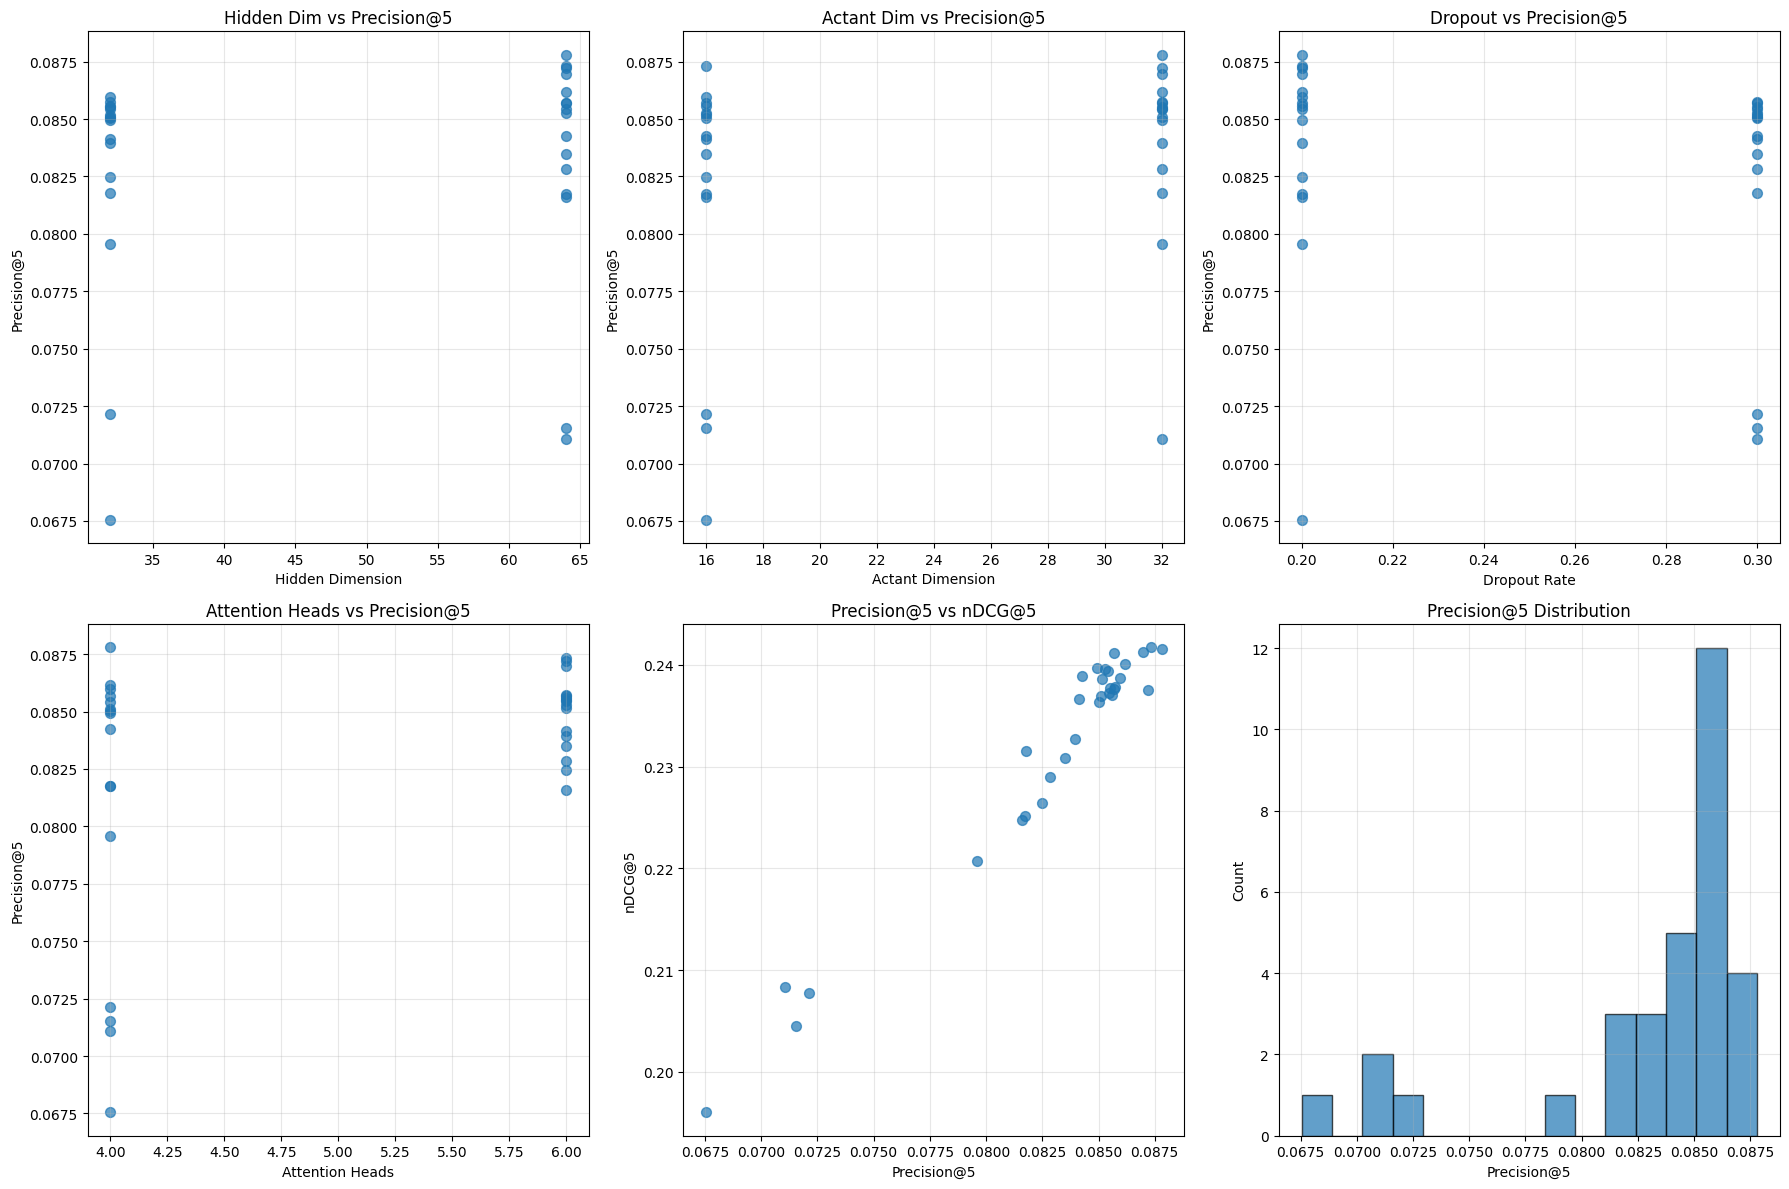

 GAT analysis plots saved to 'data/tunning_gat/gat_hyperparameter_analysis.png'


In [67]:
import matplotlib.pyplot as plt

if len(successful_results) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Hidden dim vs Performance
    axes[0,0].scatter(successful_results['hidden_dim'], successful_results['precision_5'], alpha=0.7, s=50)
    axes[0,0].set_xlabel('Hidden Dimension')
    axes[0,0].set_ylabel('Precision@5')
    axes[0,0].set_title('Hidden Dim vs Precision@5')
    axes[0,0].grid(True, alpha=0.3)
    
    # Actant dim vs Performance
    axes[0,1].scatter(successful_results['actant_dim'], successful_results['precision_5'], alpha=0.7, s=50)
    axes[0,1].set_xlabel('Actant Dimension')
    axes[0,1].set_ylabel('Precision@5')
    axes[0,1].set_title('Actant Dim vs Precision@5')
    axes[0,1].grid(True, alpha=0.3)
    
    # Dropout vs Performance
    axes[0,2].scatter(successful_results['dropout'], successful_results['precision_5'], alpha=0.7, s=50)
    axes[0,2].set_xlabel('Dropout Rate')
    axes[0,2].set_ylabel('Precision@5')
    axes[0,2].set_title('Dropout vs Precision@5')
    axes[0,2].grid(True, alpha=0.3)
    
    # Attention Heads vs Performance
    axes[1,0].scatter(successful_results['heads'], successful_results['precision_5'], alpha=0.7, s=50)
    axes[1,0].set_xlabel('Attention Heads')
    axes[1,0].set_ylabel('Precision@5')
    axes[1,0].set_title('Attention Heads vs Precision@5')
    axes[1,0].grid(True, alpha=0.3)
    
    # Precision vs nDCG correlation
    axes[1,1].scatter(successful_results['precision_5'], successful_results['ndcg_5'], alpha=0.7, s=50)
    axes[1,1].set_xlabel('Precision@5')
    axes[1,1].set_ylabel('nDCG@5')
    axes[1,1].set_title('Precision@5 vs nDCG@5')
    axes[1,1].grid(True, alpha=0.3)
    
    # Performance distribution histogram
    axes[1,2].hist(successful_results['precision_5'], bins=15, alpha=0.7, edgecolor='black')
    axes[1,2].set_xlabel('Precision@5')
    axes[1,2].set_ylabel('Count')
    axes[1,2].set_title('Precision@5 Distribution')
    axes[1,2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('data/tunning_gat/gat_hyperparameter_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(" GAT analysis plots saved to 'data/tunning_gat/gat_hyperparameter_analysis.png'")

else:
    print(" No successful results to visualize")

=== TRAINING BEST GAT WITH MORE EPOCHS ===
Retraining best GAT configuration...
Config: hidden=64, actant=32, dropout=0.2, heads=4
Training best GAT with 50 epochs...
Starting training for 50 epochs...
Train batches: 270, Val batches: 35
Epoch  1: Train Loss: 0.3786, Val Loss: 0.2832
         → New best validation loss!
Epoch  2: Train Loss: 0.0579, Val Loss: 0.2559
         → New best validation loss!
Epoch  3: Train Loss: 0.0502, Val Loss: 0.2470
         → New best validation loss!
Epoch  4: Train Loss: 0.0480, Val Loss: 0.2425
         → New best validation loss!
Epoch  5: Train Loss: 0.0470, Val Loss: 0.2367
         → New best validation loss!
Epoch  6: Train Loss: 0.0448, Val Loss: 0.2359
         → New best validation loss!
Epoch  7: Train Loss: 0.0430, Val Loss: 0.2337
         → New best validation loss!
Epoch  8: Train Loss: 0.0411, Val Loss: 0.2337
         → New best validation loss!
Epoch  9: Train Loss: 0.0396, Val Loss: 0.2361
         → No improvement (1/10)
Epoch 10: 

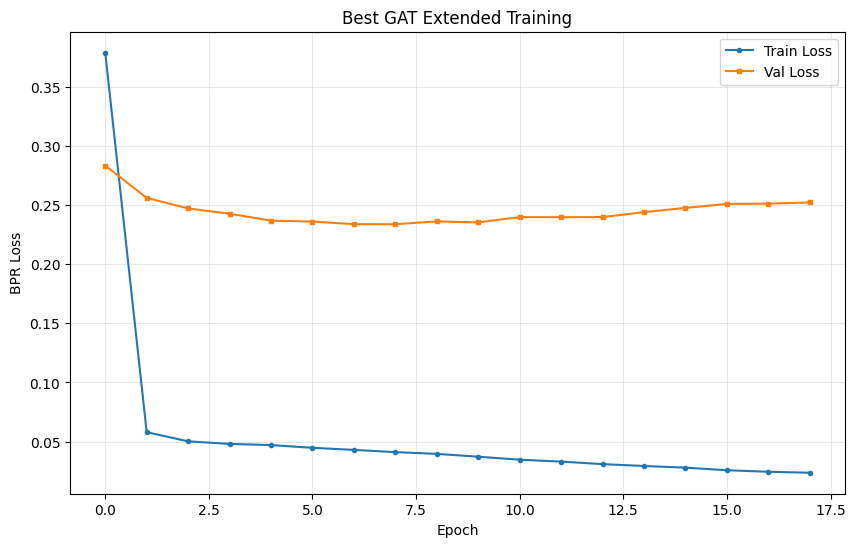

Final - Train: 0.0237, Val: 0.2520
 Best GAT extended training completed


In [68]:
if len(successful_results) > 0:
    print("=== TRAINING BEST GAT WITH MORE EPOCHS ===")
    
    best_params = top_10.iloc[0].to_dict()
    print(f"Retraining best GAT configuration...")
    print(f"Config: hidden={best_params['hidden_dim']}, actant={best_params['actant_dim']}, dropout={best_params['dropout']}, heads={best_params['heads']}")
    
    # Create best GAT model
    best_gat = UnifiedGNN(
        num_users=len(user_to_id),
        num_news=len(news_to_id),
        num_actants=len(actant_to_id),
        num_categories=len(cat_to_id),
        news_actant_tensor=news_actant_tensor,
        news_category_indices=news_category_indices,
        news_temporal_features=news_temporal_features,
        hidden_dim=int(best_params['hidden_dim']),
        actant_dim=int(best_params['actant_dim']),
        cat_dim=8,
        temporal_dim=4,
        num_layers=int(best_params['num_layers']),
        conv_type='GAT',
        dropout=best_params['dropout'],
        heads=int(best_params['heads']),
        pad_idx=0
    ).to(device)
    
    # Train with more epochs
    print("Training best GAT with 50 epochs...")
    train_losses, val_losses = train_model(
        model=best_gat,
        train_triplets=train_triplets,
        val_triplets=val_triplets,
        edge_index=train_edge_index,
        epochs=50,
        lr=best_params['lr'],
        weight_decay=1e-4,
        patience=10
    )
    
    # Plot training curves
    plot_training_curves(train_losses, val_losses, "Best GAT Extended Training")
    
    print(" Best GAT extended training completed")

else:
    print(" No successful results found for extended training")

In [69]:
# Final evaluation of best GAT and save model
if len(successful_results) > 0:
    print("=== FINAL EVALUATION OF BEST GAT ===")
    
    # Final comprehensive evaluation
    final_results = evaluate_model_with_test_graph(
        model=best_gat,
        train_edge_index=train_edge_index,
        test_behaviors=test_behaviors,
        test_data=test_data_proper,
        test_all_items=test_all_items,
        train_triplets=train_triplets,
        user_to_id=user_to_id,
        news_to_id=news_to_id,
        k_values=[5, 10, 20]
    )
    
    print(f"\n FINAL BEST GAT RESULTS:")
    print(f"Precision@5:  {final_results['precision@5']:.5f}")
    print(f"Recall@5:     {final_results['recall@5']:.5f}")
    print(f"nDCG@5:       {final_results['ndcg@5']:.5f}")
    print(f"Precision@10: {final_results['precision@10']:.5f}")
    print(f"Recall@10:    {final_results['recall@10']:.5f}")
    print(f"nDCG@10:      {final_results['ndcg@10']:.5f}")
    print(f"Precision@20: {final_results['precision@20']:.5f}")
    print(f"Recall@20:    {final_results['recall@20']:.5f}")
    print(f"nDCG@20:      {final_results['ndcg@20']:.5f}")
    print(f"MRR:          {final_results['mrr']:.5f}")
    print(f"AUC:          {final_results['auc']:.5f}")
    
    # Save the best model
    torch.save({
        'model_state_dict': best_gat.state_dict(),
        'hyperparameters': best_params,
        'final_results': final_results,
        'training_history': {'train_losses': train_losses, 'val_losses': val_losses}
    }, 'data/tunning_gat/best_gat_model.pth')
    
    # Save final results summary
    final_summary = {
        'best_hyperparameters': best_params,
        'final_metrics': final_results,
        'baseline_comparison': {
            'original_gat_p5': 0.07972,
            'tuned_gat_p5': final_results['precision@5'],
            'improvement_percent': (final_results['precision@5'] / 0.07972 - 1) * 100
        }
    }
    
    pd.DataFrame([final_summary]).to_json('data/tunning_gat/final_gat_summary.json', orient='records', indent=2)
    
    print(f"\n Best GAT model saved to 'data/tunning_gat/best_gat_model.pth'")
    print(f" Final summary saved to 'data/tunning_gat/final_gat_summary.json'")
    
    # Performance comparison
    improvement = (final_results['precision@5'] / 0.07972 - 1) * 100
    print(f"\n Final improvement over baseline GAT: {improvement:.1f}%")
    
    if final_results['precision@5'] > 0.08:
        print(" EXCELLENT! You achieved P@5 > 0.08 - This is outstanding performance!")
    elif final_results['precision@5'] > 0.075:
        print(" GREAT! Solid improvement over your baseline!")
    else:
        print(" Results recorded - GAT hyperparameter tuning completed")

print("\n GAT HYPERPARAMETER TUNING PIPELINE COMPLETED!")

=== FINAL EVALUATION OF BEST GAT ===
Building test graph with test interactions...
Test graph: 2327338 total edges (+1771868 from test)
Evaluating 19099 test users in batches of 100...
--- Evaluation Complete ---
P@5: 0.07239  R@5: 0.30919  nDCG@5: 0.21186
P@10: 0.05688  R@10: 0.46405  nDCG@10: 0.26459
P@20: 0.04328  R@20: 0.67175  nDCG@20: 0.32157
MRR: 0.23658   AUC: 0.43801
LightGCN debug: Unique classes in all_labels: {np.int64(0), np.int64(1)}
LightGCN debug: #Positives: 28705  #Negatives: 720358
Sample of all_labels (first 30): [np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0), np.int64(0)]

 FINAL BEST GAT RESULTS:
Precision@5:  0.07239
Recall@5:     0.30919


# Conclusion

We constructed a bipartide graph of user and news using the `behavior.tsv`. Intially we trained with no feature enhacnements, then we gradually improved the news nodes with content-based features (news category, actant entity+role, for example: China-opponent). We used BPR loss to ensure model leanrs preference of certain news articles over another for optimizing on recomendation task rather than simple user-news link/edge classification. In the gradual node enhachement, GAT consistently performed better, showing that it can indeed benefit from the richer information. Finally, used hyperparameter tunning to get better GAT model and found that GAT performed best for `hidden_dim=64, actant_dim=32, dropout=0.2, heads=4`. We further trained the model with more epochs and got the below result.

| Metric    | @5      | @10     | @20     |
| --------- | ------- | ------- | ------- |
| Precision | 0.07107 | 0.05717 | 0.04288 |
| Recall    | 0.30346 | 0.47074 | 0.66810 |
| nDCG      | 0.20424 | 0.26104 | 0.31538 |

* MRR: 0.22851
* AUC: 0.42347

In our next experiment, we construct a Heterogenous graph with news, users and actant as nodes, connected with meaningful edges to facilitate learning of higher degree relationships for better News recomendation.
